# Modelo de concesión de crédito: construcción, optimización y auditoría con XAI

**Componentes del grupo:** [Nombres de los componentes del grupo]

---

## Objetivo

Se construye, optimiza y audita un modelo de concesión de crédito a partir del histórico de clientes disponible en `cs_construccion.csv`. El modelo debe decidir, para cada cliente del fichero de producción `cs_produccion.csv`, si se le concede o se le deniega el crédito, bajo dos escenarios de coste distintos:

| Escenario | Coste Falso Positivo | Coste Falso Negativo | Fichero de salida |
|---|---|---|---|
| 1 | 1 | 1 | `data/cs_produccion1.csv` |
| 2 | 1 | 10 | `data/cs_produccion2.csv` |

La variable objetivo es `SeriousDlqin2yrs` (1 = el cliente sufrió un impago grave en los dos años siguientes). La convención de decisión adoptada es:

- **Predicción 1 (positivo)** → se estima que el cliente impagará → **se deniega** el crédito.
- **Predicción 0 (negativo)** → se estima que el cliente pagará → **se concede** el crédito.

Con esta convención, un **falso positivo** es denegar el crédito a un cliente que habría pagado (coste de oportunidad: se pierde un buen cliente), y un **falso negativo** es conceder el crédito a un cliente que impaga (coste directo: se pierde el capital prestado). El escenario 2 refleja la realidad bancaria habitual: perder el capital cuesta bastante más que perder un cliente.

## Estructura del documento

1. Carga y exploración de los datos (EDA)
2. Limpieza y estandarización coherente entre construcción y producción
3. Partición y modelos supervisados (baseline logístico y Gradient Boosting)
4. Optimización del umbral de decisión por coste
5. Generación de las predicciones de producción
6. Auditoría XAI: modelo surrogado, SHAP global y local, contrafactuales, importancia por permutación y dependencia parcial
7. Enfoque alternativo con Multiarmed Bandit contextual
8. Resumen de resultados y reflexión final

## 1. Configuración del entorno

Se cargan las librerías de trabajo y se fija una semilla global para que todos los resultados sean reproducibles. Se establece también un estilo gráfico homogéneo para todas las figuras del documento.

In [47]:
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

SEED = 42
rng = np.random.default_rng(SEED)

sns.set_theme(style="whitegrid", palette="deep")
plt.rcParams["figure.dpi"] = 100
pd.options.display.max_columns = None
pd.options.display.float_format = "{:.4f}".format

## 2. Carga de los datos

Se cargan los dos ficheros de trabajo y el diccionario de datos. El fichero de construcción contiene el histórico etiquetado con el que se entrena y valida el modelo; el de producción contiene los clientes nuevos sobre los que hay que decidir, sin etiqueta. El diccionario describe el significado de cada variable: la mayoría son medidas de endeudamiento (utilización de líneas de crédito, ratio de deuda), capacidad de pago (ingreso mensual) e historial de morosidad (número de retrasos de 30-59, 60-89 y más de 90 días).

In [48]:
df_cons = pd.read_csv("data/cs_construccion.csv")
df_prod = pd.read_csv("data/cs_produccion.csv")
dicc = pd.read_csv("data/DataDictionary.csv", sep=";").drop("Unnamed: 0", axis=1).set_index("Variable Name")

TARGET = "SeriousDlqin2yrs"

print("Construcción:", df_cons.shape)
print("Producción:  ", df_prod.shape)

pd.options.display.max_colwidth = None
dicc

Construcción: (105000, 11)
Producción:   (45000, 11)


,Description,Type
Variable Name,,
SeriousDlqin2yrs,Person experienced 90 days past due delinquency or worse,Y/N
RevolvingUtilizationOfUnsecuredLines,Total balance on credit cards and personal lines of credit except real estate and no installment debt like car loans divided by the sum of credit limits,percentage
age,Age of borrower in years,integer
NumberOfTime30-59DaysPastDueNotWorse,Number of times borrower has been 30-59 days past due but no worse in the last 2 years.,integer
DebtRatio,"Monthly debt payments, alimony,living costs divided by monthy gross income",percentage
MonthlyIncome,Monthly income,real
NumberOfOpenCreditLinesAndLoans,Number of Open loans (installment like car loan or mortgage) and Lines of credit (e.g. credit cards),integer
NumberOfTimes90DaysLate,Number of times borrower has been 90 days or more past due.,integer
NumberRealEstateLoansOrLines,Number of mortgage and real estate loans including home equity lines of credit,integer


Se comprueba que el fichero de producción trae la columna del target completamente vacía (es la incógnita a predecir), por lo que se elimina para trabajar solo con las variables explicativas. Un punto clave que condiciona todo el desarrollo posterior: **en producción hay que emitir una decisión para los 45.000 clientes**, de modo que ninguna transformación de limpieza puede eliminar filas de ese fichero.

In [49]:
print("Valores no nulos del target en producción:", df_prod[TARGET].notna().sum())
df_prod = df_prod.drop(columns=[TARGET])

FEATURES_BASE = list(df_prod.columns)
df_cons.head()

Valores no nulos del target en producción: 0


,SeriousDlqin2yrs,RevolvingUtilizationOfUnsecuredLines,age,NumberOfTime30-59DaysPastDueNotWorse,DebtRatio,MonthlyIncome,NumberOfOpenCreditLinesAndLoans,NumberOfTimes90DaysLate,NumberRealEstateLoansOrLines,NumberOfTime60-89DaysPastDueNotWorse,NumberOfDependents
0,0,0.0906,59,0,0.2893,7466.0000,17,0,2,0,1.0000
1,0,0.0193,74,0,1.5055,541.0000,16,0,1,0,0.0000
2,0,0.6700,34,0,0.0815,7816.0000,9,0,0,0,0.0000
3,0,1.0000,66,0,0.2091,6000.0000,4,0,1,0,0.0000
4,0,0.1381,65,1,100.0000,NaN,2,0,0,0,NaN


## 3. Análisis exploratorio (EDA)

### 3.1 Estadísticos descriptivos

Se revisan los estadísticos básicos de cada variable. A primera vista destacan varios problemas de calidad de datos que habrá que tratar: máximos absurdos en `RevolvingUtilizationOfUnsecuredLines` y `DebtRatio` (miles, cuando son ratios que deberían moverse en torno a 0-1), valores 96/98 en las variables de morosidad (que por su repetición exacta apuntan a códigos especiales y no a recuentos reales), y valores ausentes en `MonthlyIncome` y `NumberOfDependents`.

In [50]:
df_cons.describe().T[["count", "mean", "std", "min", "25%", "50%", "75%", "max"]]

,count,mean,std,min,25%,50%,75%,max
SeriousDlqin2yrs,105000.0000,0.0668,0.2497,0.0000,0.0000,0.0000,0.0000,1.0000
RevolvingUtilizationOfUnsecuredLines,105000.0000,6.1470,217.6814,0.0000,0.0299,0.1547,0.5611,22198.0000
age,105000.0000,52.2216,14.7657,0.0000,41.0000,52.0000,63.0000,109.0000
NumberOfTime30-59DaysPastDueNotWorse,105000.0000,0.4199,4.1890,0.0000,0.0000,0.0000,0.0000,98.0000
DebtRatio,105000.0000,354.1605,1999.4554,0.0000,0.1749,0.3661,0.8692,329664.0000
MonthlyIncome,84205.0000,6700.4392,15368.2100,0.0000,3400.0000,5400.0000,8250.0000,3008750.0000
NumberOfOpenCreditLinesAndLoans,105000.0000,8.4403,5.1309,0.0000,5.0000,8.0000,11.0000,58.0000
NumberOfTimes90DaysLate,105000.0000,0.2651,4.1660,0.0000,0.0000,0.0000,0.0000,98.0000
NumberRealEstateLoansOrLines,105000.0000,1.0164,1.1340,0.0000,0.0000,1.0000,2.0000,54.0000
NumberOfTime60-89DaysPastDueNotWorse,105000.0000,0.2393,4.1519,0.0000,0.0000,0.0000,0.0000,98.0000


### 3.2 Distribución de la variable objetivo

Se cuantifica el desbalanceo de clases. Solo en torno a un 7% de los clientes del histórico acaba en impago grave, algo esperable en carteras de crédito. Este desbalanceo tiene dos implicaciones prácticas: la exactitud (accuracy) no es una métrica útil (un modelo que concediera siempre acertaría un 93% de las veces siendo inservible), y el umbral de decisión sobre la probabilidad tendrá que elegirse con cuidado, sobre todo en el escenario de costes asimétricos.

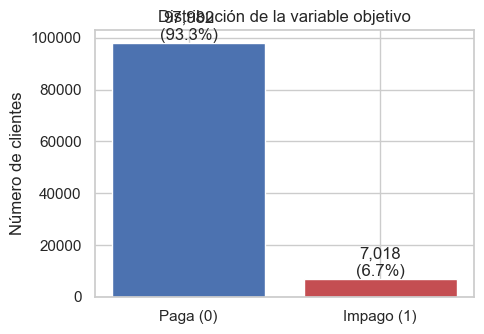

In [51]:
counts = df_cons[TARGET].value_counts()

fig, ax = plt.subplots(figsize=(5, 3.5))
ax.bar(["Paga (0)", "Impago (1)"], counts.values, color=["#4c72b0", "#c44e52"])
for i, v in enumerate(counts.values):
    ax.text(i, v, f"{v:,}\n({100*v/len(df_cons):.1f}%)", ha="center", va="bottom")
ax.set_ylabel("Número de clientes")
ax.set_title("Distribución de la variable objetivo")
plt.tight_layout()
plt.show()

### 3.3 Valores ausentes

Se mide el porcentaje de valores ausentes por variable y, más importante, si la ausencia es informativa. Casi un 20% de los clientes no tiene informado el ingreso mensual. Antes de decidir cómo tratarlo se compara la tasa de impago entre quienes tienen y no tienen ingreso informado: si difieren, la propia ausencia lleva señal y conviene conservarla como variable en lugar de tirar las filas. Y difieren: los clientes sin ingreso informado impagan algo **menos** (5.5% frente a 7.0%), un resultado contraintuitivo que confirma que la ausencia no es aleatoria. Descartar el 20% del histórico sería además incoherente con producción, donde esos clientes también existen y hay que puntuarlos igualmente.

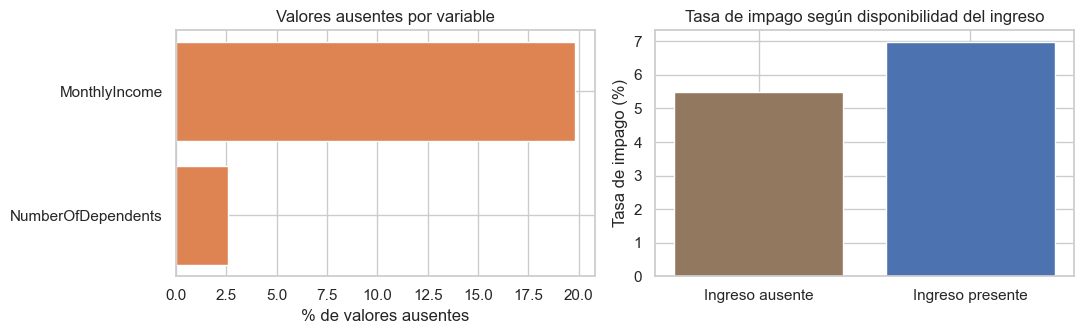

Tasa de impago con ingreso ausente:  5.49%
Tasa de impago con ingreso presente: 6.98%


In [52]:
na_pct = 100 * df_cons.isna().mean()
na_pct = na_pct[na_pct > 0].sort_values()

tasa_con_na = df_cons.loc[df_cons["MonthlyIncome"].isna(), TARGET].mean()
tasa_sin_na = df_cons.loc[df_cons["MonthlyIncome"].notna(), TARGET].mean()

fig, axes = plt.subplots(1, 2, figsize=(11, 3.5))
axes[0].barh(na_pct.index, na_pct.values, color="#dd8452")
axes[0].set_xlabel("% de valores ausentes")
axes[0].set_title("Valores ausentes por variable")

axes[1].bar(["Ingreso ausente", "Ingreso presente"],
            [100 * tasa_con_na, 100 * tasa_sin_na], color=["#937860", "#4c72b0"])
axes[1].set_ylabel("Tasa de impago (%)")
axes[1].set_title("Tasa de impago según disponibilidad del ingreso")
plt.tight_layout()
plt.show()

print(f"Tasa de impago con ingreso ausente:  {tasa_con_na:.2%}")
print(f"Tasa de impago con ingreso presente: {tasa_sin_na:.2%}")

### 3.4 Distribución de las variables

Se representan los histogramas de todas las variables explicativas. Para las tres con colas extremadamente largas (`RevolvingUtilizationOfUnsecuredLines`, `DebtRatio` y `MonthlyIncome`) se usa escala logarítmica, ya que en escala natural toda la masa quedaría comprimida en el primer bin. Se aprecia que la edad tiene una distribución razonable y suave, que las variables de recuento están muy concentradas en cero, y que las variables de ratio presentan una mezcla de dos regímenes (valores en 0-1 más una cola de valores anómalos de miles).

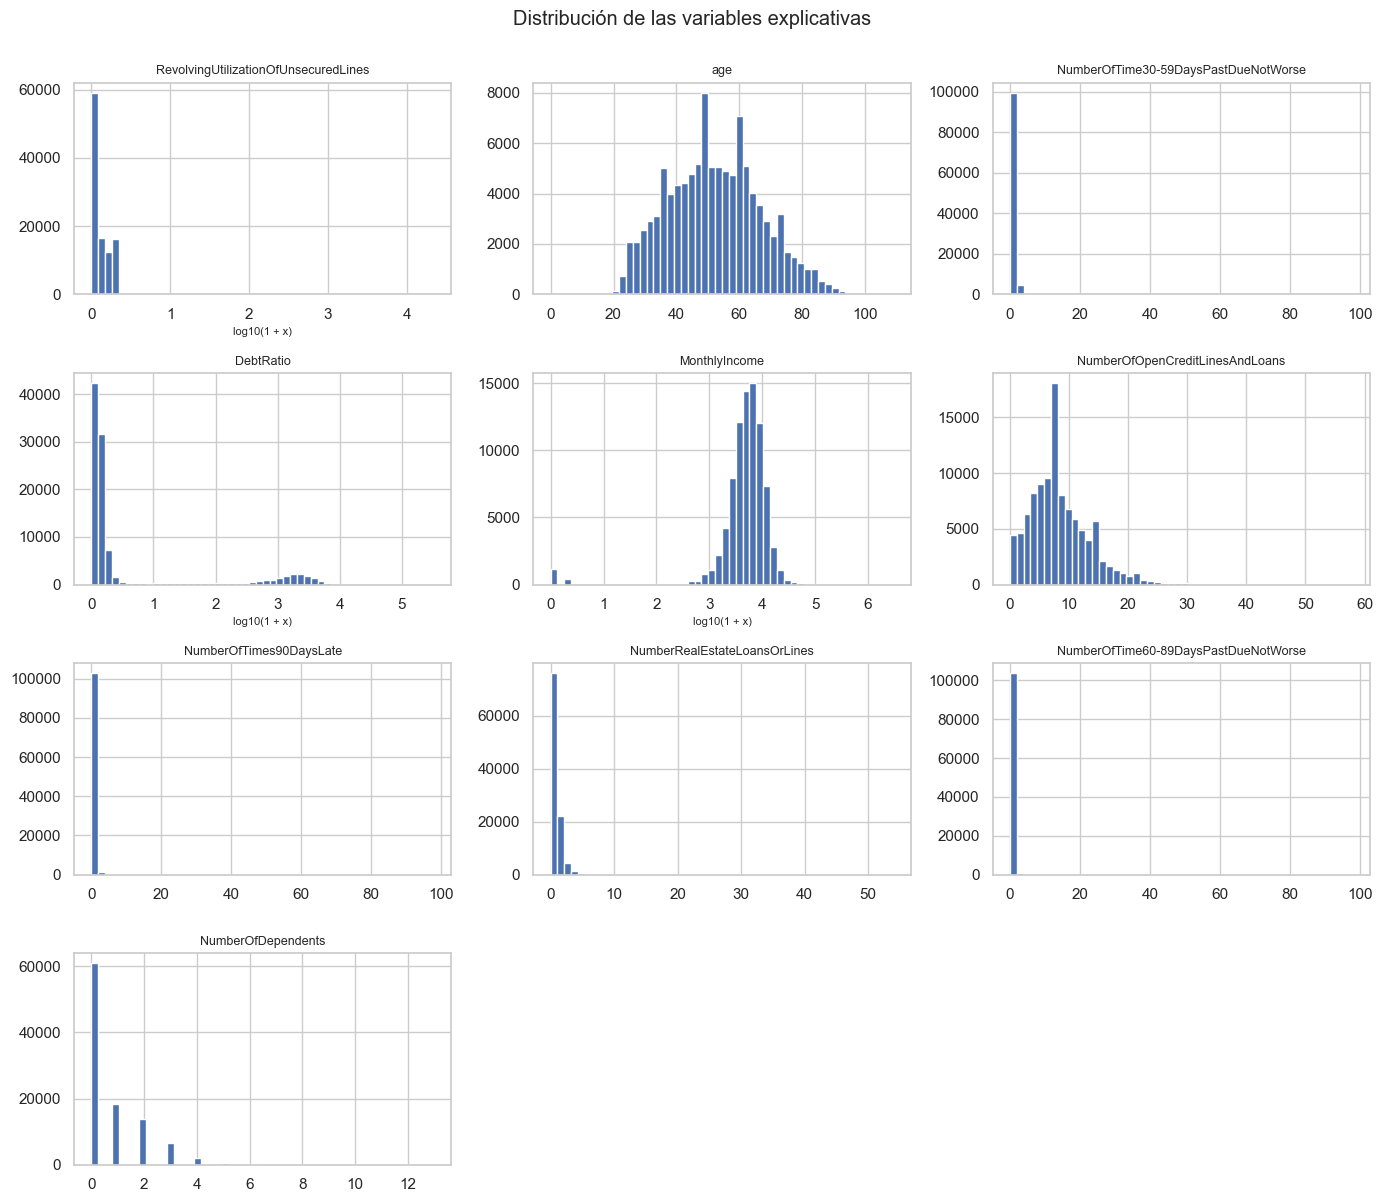

In [53]:
LOG_VARS = ["RevolvingUtilizationOfUnsecuredLines", "DebtRatio", "MonthlyIncome"]

fig, axes = plt.subplots(4, 3, figsize=(14, 12))
for ax, col in zip(axes.flat, FEATURES_BASE):
    datos = df_cons[col].dropna()
    if col in LOG_VARS:
        datos = np.log10(datos + 1)
        ax.set_xlabel("log10(1 + x)", fontsize=8)
    ax.hist(datos, bins=50, color="#4c72b0")
    ax.set_title(col, fontsize=9)
for ax in axes.flat[len(FEATURES_BASE):]:
    ax.axis("off")
plt.suptitle("Distribución de las variables explicativas", y=1.0)
plt.tight_layout()
plt.show()

### 3.5 Anomalías detectadas

Se cuantifican las tres anomalías señaladas en los descriptivos:

- **Códigos 96/98 en morosidad**: aparecen siempre en las tres variables a la vez, lo que confirma que son códigos administrativos (por ejemplo, "sin información" o "situación especial") y no recuentos reales. Eso sí, la tasa de impago de esos clientes es altísima, así que el código lleva mucha señal y no conviene destruirla.
- **`RevolvingUtilization` > 1**: una utilización por encima del 100% del límite es posible (sobregiros), pero valores de cientos o miles son errores de registro.
- **`DebtRatio` anómalo cuando falta el ingreso**: al ser un cociente sobre el ingreso, cuando este no está informado el ratio aparece con valores absurdos. Ambos problemas están relacionados y se tratarán con capado.
- **Edad 0**: imposible en un solicitante de crédito; se localiza cuántas filas afecta.

In [54]:
MOROSIDAD = ["NumberOfTime30-59DaysPastDueNotWorse",
             "NumberOfTime60-89DaysPastDueNotWorse",
             "NumberOfTimes90DaysLate"]

con_codigo = (df_cons[MOROSIDAD] >= 96).any(axis=1)
print(f"Filas con código 96/98 en alguna variable de morosidad: {con_codigo.sum()}")
print(f"  ... y en las tres a la vez: {(df_cons[MOROSIDAD] >= 96).all(axis=1).sum()}")
print(f"  Tasa de impago en esas filas: {df_cons.loc[con_codigo, TARGET].mean():.1%}"
      f"  (global: {df_cons[TARGET].mean():.1%})")
print()
ruul = df_cons["RevolvingUtilizationOfUnsecuredLines"]
print(f"Clientes con RevolvingUtilization > 1:  {(ruul > 1).sum():,}")
print(f"Clientes con RevolvingUtilization > 10: {(ruul > 10).sum():,}")
print()
print(f"Mediana de DebtRatio con ingreso presente: "
      f"{df_cons.loc[df_cons['MonthlyIncome'].notna(), 'DebtRatio'].median():.2f}")
print(f"Mediana de DebtRatio con ingreso ausente:  "
      f"{df_cons.loc[df_cons['MonthlyIncome'].isna(), 'DebtRatio'].median():.2f}")
print()
print(f"Filas con edad = 0: {(df_cons['age'] == 0).sum()}")

Filas con código 96/98 en alguna variable de morosidad: 188
  ... y en las tres a la vez: 188
  Tasa de impago en esas filas: 54.3%  (global: 6.7%)

Clientes con RevolvingUtilization > 1:  2,383
Clientes con RevolvingUtilization > 10: 176

Mediana de DebtRatio con ingreso presente: 0.30
Mediana de DebtRatio con ingreso ausente:  1181.00

Filas con edad = 0: 1


### 3.6 Tasa de impago por segmentos

Se analiza cómo varía la tasa de impago a lo largo de tres ejes clásicos del riesgo de crédito: edad, nivel de ingresos e historial de morosidad. Este tipo de curvas es el análisis univariante estándar en scoring, porque anticipa qué variables van a resultar predictivas y en qué dirección:

- La tasa de impago **cae de forma monótona con la edad**: los solicitantes jóvenes son sistemáticamente más arriesgados.
- También **cae con el ingreso**, aunque el efecto se aplana en los deciles altos.
- El efecto más brutal es el del **historial**: basta un retraso previo de más de 90 días para que la tasa de impago se multiplique varias veces, y con dos o más se dispara.

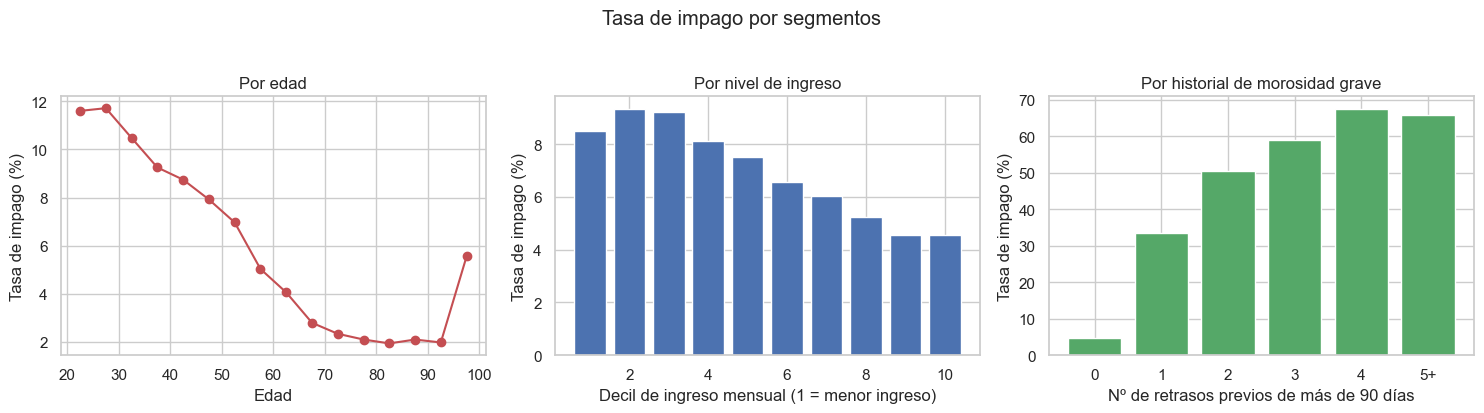

In [55]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

tramos_edad = pd.cut(df_cons["age"], bins=range(20, 105, 5))
tasa_edad = df_cons.groupby(tramos_edad, observed=True)[TARGET].mean()
axes[0].plot([iv.mid for iv in tasa_edad.index], 100 * tasa_edad.values,
             marker="o", color="#c44e52")
axes[0].set_xlabel("Edad")
axes[0].set_ylabel("Tasa de impago (%)")
axes[0].set_title("Por edad")

con_ingreso = df_cons.dropna(subset=["MonthlyIncome"])
deciles = pd.qcut(con_ingreso["MonthlyIncome"], 10, duplicates="drop")
tasa_ingreso = con_ingreso.groupby(deciles, observed=True)[TARGET].mean()
axes[1].bar(range(1, len(tasa_ingreso) + 1), 100 * tasa_ingreso.values, color="#4c72b0")
axes[1].set_xlabel("Decil de ingreso mensual (1 = menor ingreso)")
axes[1].set_ylabel("Tasa de impago (%)")
axes[1].set_title("Por nivel de ingreso")

previos = df_cons["NumberOfTimes90DaysLate"].where(
    df_cons["NumberOfTimes90DaysLate"] < 96).clip(upper=5)
tasa_previos = df_cons.groupby(previos)[TARGET].mean()
axes[2].bar([str(int(i)) if i < 5 else "5+" for i in tasa_previos.index],
            100 * tasa_previos.values, color="#55a868")
axes[2].set_xlabel("Nº de retrasos previos de más de 90 días")
axes[2].set_ylabel("Tasa de impago (%)")
axes[2].set_title("Por historial de morosidad grave")

plt.suptitle("Tasa de impago por segmentos", y=1.03)
plt.tight_layout()
plt.show()

### 3.7 Separación de clases por variable

Se comparan las distribuciones de cada variable entre clientes que pagan y clientes que impagan mediante boxplots (sin outliers para que la escala sea legible, y en log para las variables de cola larga). Las variables donde las cajas se separan más son las candidatas a dominar el modelo: la utilización de líneas de crédito y los contadores de morosidad muestran una separación clara, mientras que otras como el número de dependientes apenas discriminan por sí solas.

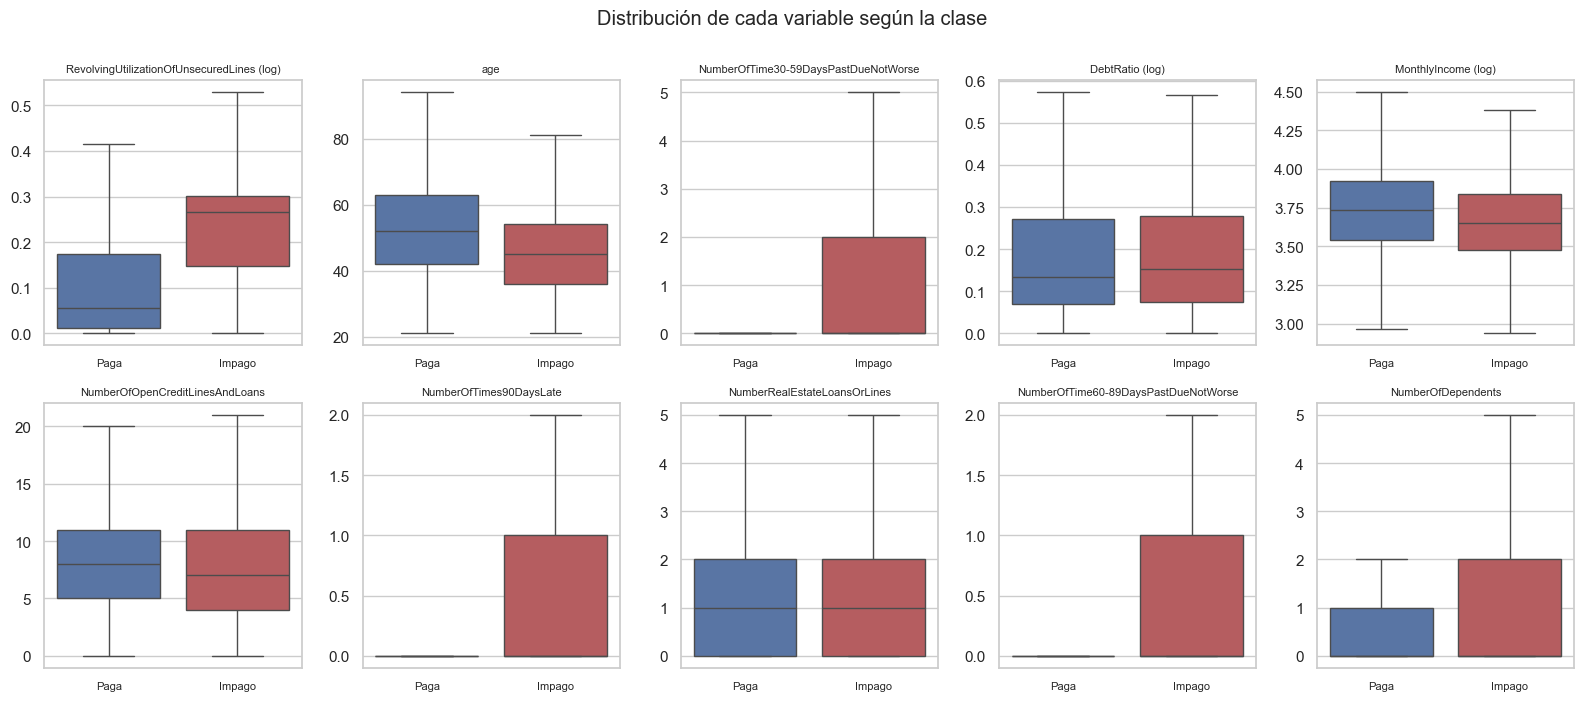

In [56]:
fig, axes = plt.subplots(2, 5, figsize=(16, 7))
for ax, col in zip(axes.flat, FEATURES_BASE):
    datos = df_cons[[col, TARGET]].dropna().copy()
    if col in LOG_VARS:
        datos[col] = np.log10(datos[col] + 1)
    sns.boxplot(data=datos, x=TARGET, y=col, hue=TARGET, ax=ax, showfliers=False,
                palette=["#4c72b0", "#c44e52"], legend=False)
    ax.set_title(col + (" (log)" if col in LOG_VARS else ""), fontsize=8)
    ax.set_xlabel("")
    ax.set_ylabel("")
    ax.set_xticks([0, 1])
    ax.set_xticklabels(["Paga", "Impago"], fontsize=8)
plt.suptitle("Distribución de cada variable según la clase", y=1.0)
plt.tight_layout()
plt.show()

### 3.8 Correlaciones

Se calcula la matriz de correlación de Spearman (basada en rangos, robusta frente a las colas extremas que se acaban de ver, al contrario que Pearson). Los tres contadores de morosidad están correlacionados entre sí y son los más asociados al target. También se observa la correlación natural entre número de líneas de crédito abiertas y préstamos inmobiliarios, y entre edad y las demás variables de ciclo de vida. No hay pares con correlación tan alta como para justificar eliminar variables: los modelos de árboles gestionan bien la redundancia moderada.

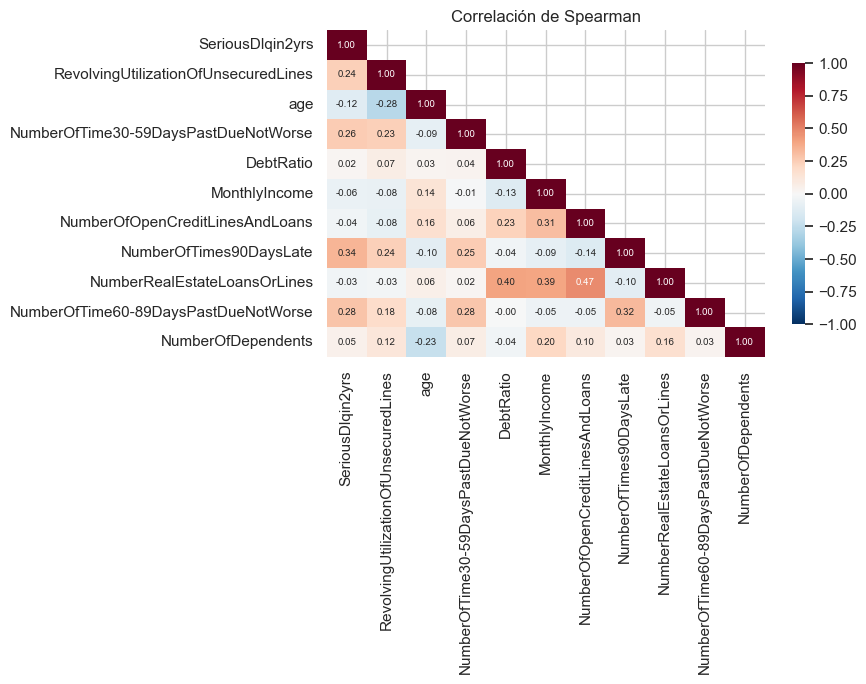

In [57]:
corr = df_cons.corr(method="spearman")

fig, ax = plt.subplots(figsize=(9, 7))
mask = np.triu(np.ones_like(corr, dtype=bool), k=1)
sns.heatmap(corr, mask=mask, cmap="RdBu_r", vmin=-1, vmax=1, annot=True, fmt=".2f",
            annot_kws={"size": 7}, cbar_kws={"shrink": 0.8}, ax=ax)
ax.set_title("Correlación de Spearman")
plt.tight_layout()
plt.show()

### 3.9 Visión global: proyección PCA

Se proyectan los clientes sobre las dos primeras componentes principales (tras imputar con la mediana y estandarizar, requisitos del PCA). El objetivo no es modelizar sino visualizar: comprobar si las clases forman grupos separables a simple vista. Se observa que los impagos no forman un clúster aparte, sino que se concentran en una zona del espacio solapada con la clase mayoritaria. Esto anticipa que el problema no es trivialmente separable y que la salida natural del modelo será una probabilidad graduada, no una frontera nítida.

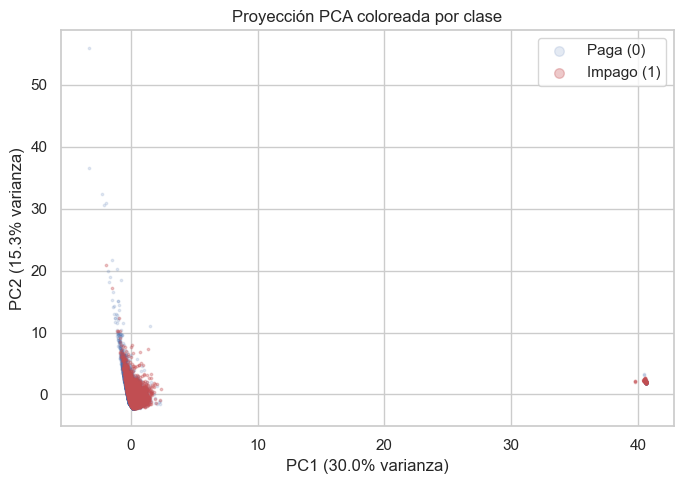

In [58]:
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
from sklearn.impute import SimpleImputer

X_eda = SimpleImputer(strategy="median").fit_transform(df_cons[FEATURES_BASE])
X_eda = StandardScaler().fit_transform(X_eda)
pca = PCA(n_components=2, random_state=SEED)
X_pca = pca.fit_transform(X_eda)

y_eda = df_cons[TARGET].values
fig, ax = plt.subplots(figsize=(7, 5))
ax.scatter(X_pca[y_eda == 0, 0], X_pca[y_eda == 0, 1], s=3, alpha=0.15,
           label="Paga (0)", color="#4c72b0")
ax.scatter(X_pca[y_eda == 1, 0], X_pca[y_eda == 1, 1], s=3, alpha=0.30,
           label="Impago (1)", color="#c44e52")
ax.set_xlabel(f"PC1 ({100*pca.explained_variance_ratio_[0]:.1f}% varianza)")
ax.set_ylabel(f"PC2 ({100*pca.explained_variance_ratio_[1]:.1f}% varianza)")
ax.set_title("Proyección PCA coloreada por clase")
ax.legend(markerscale=4)
plt.tight_layout()
plt.show()

## 4. Limpieza y estandarización de los datos

Se encapsula toda la limpieza en una única función aplicable de forma idéntica a construcción y a producción. Este es el punto crítico de diseño: cualquier asimetría entre lo que ve el modelo en entrenamiento y lo que ve en producción invalida la estimación del coste. Las decisiones tomadas, justificadas por lo visto en el EDA:

- **No se eliminan filas** dentro de la función (en producción es imposible). La única excepción, fuera de la función y solo en construcción, son las filas con edad 0, que son errores puros.
- **Flags de información ausente/especial**: se crean `IngresoAusente` (la ausencia de ingreso demostró tener tasa de impago distinta) y `CodigoMoraEspecial` (los códigos 96/98 identifican un colectivo con impago altísimo). Así la señal se conserva de forma explícita e interpretable.
- **Códigos 96/98** en morosidad: se sustituyen por un tope de 20, por encima del máximo legítimo observado. Se mantiene así el orden "muchos retrasos = peor" sin dejar que un código administrativo distorsione la escala.
- **Capado (winsorización) al percentil 99** de `RevolvingUtilization`, `DebtRatio` y `MonthlyIncome`, con topes calculados **solo sobre construcción** y reutilizados en producción (evita fuga de información y garantiza el mismo tratamiento). A los árboles apenas les afecta (trabajan con ordenaciones), pero estabiliza los análisis SHAP, los gráficos y el modelo lineal de referencia.
- **Los NaN se dejan como están**: el modelo elegido después (Gradient Boosting por histogramas) los trata de forma nativa aprendiendo la mejor rama para "valor ausente", que es exactamente lo que se quiere dado que la ausencia es informativa.

In [59]:
CAP_MORA = 20

def limpiar(df, caps=None):
    '''Limpieza homogénea. No elimina filas: producción exige decisión por cliente.'''
    df = df.copy()

    # Flags informativos (se crean antes de modificar nada)
    df["IngresoAusente"] = df["MonthlyIncome"].isna().astype(int)
    df["CodigoMoraEspecial"] = (df[MOROSIDAD] >= 96).any(axis=1).astype(int)

    # Códigos administrativos 96/98 -> tope que conserva el orden
    for col in MOROSIDAD:
        df[col] = df[col].where(df[col] < 96, CAP_MORA)

    # Capado de colas extremas al percentil 99 de construcción
    if caps is None:
        caps = {c: df[c].quantile(0.99)
                for c in ["RevolvingUtilizationOfUnsecuredLines", "DebtRatio", "MonthlyIncome"]}
    for c, v in caps.items():
        df[c] = df[c].clip(upper=v)

    return df, caps

df_cons_l = df_cons[df_cons["age"] > 0].reset_index(drop=True)
df_cons_l, caps = limpiar(df_cons_l)
df_prod_l, _ = limpiar(df_prod, caps=caps)

FEATURES = FEATURES_BASE + ["IngresoAusente", "CodigoMoraEspecial"]

print("Construcción tras limpieza:", df_cons_l.shape)
print("Producción tras limpieza:  ", df_prod_l.shape)
print("\nTopes aplicados (percentil 99 de construcción):")
for c, v in caps.items():
    print(f"  {c}: {v:,.2f}")

Construcción tras limpieza: (104999, 13)
Producción tras limpieza:   (45000, 12)

Topes aplicados (percentil 99 de construcción):
  RevolvingUtilizationOfUnsecuredLines: 1.11
  DebtRatio: 4,999.02
  MonthlyIncome: 25,000.00


Se comprueba visualmente el efecto del capado sobre las dos variables más problemáticas. La forma del grueso de la distribución no cambia; lo único que desaparece es la cola de valores extremos (errores de registro y ratios calculados sin ingreso), que queda concentrada en el valor tope.

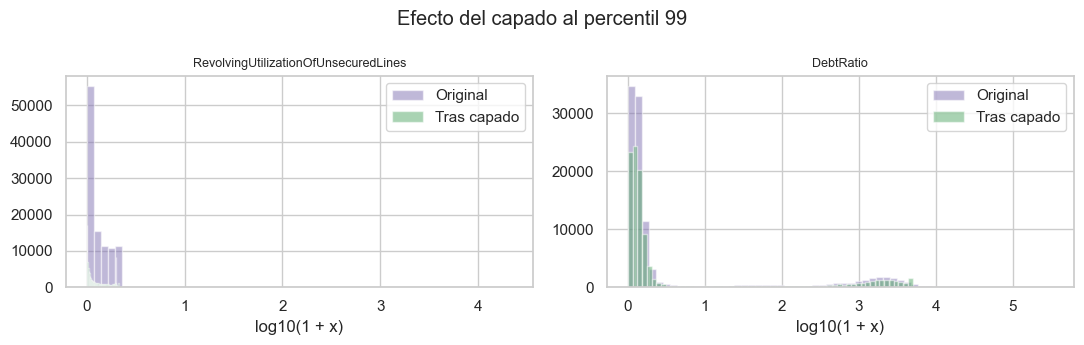

In [60]:
fig, axes = plt.subplots(1, 2, figsize=(11, 3.5))
for ax, col in zip(axes, ["RevolvingUtilizationOfUnsecuredLines", "DebtRatio"]):
    ax.hist(np.log10(df_cons[col].dropna() + 1), bins=60, alpha=0.5,
            label="Original", color="#8172b3")
    ax.hist(np.log10(df_cons_l[col].dropna() + 1), bins=60, alpha=0.5,
            label="Tras capado", color="#55a868")
    ax.set_title(col, fontsize=9)
    ax.set_xlabel("log10(1 + x)")
    ax.legend()
plt.suptitle("Efecto del capado al percentil 99")
plt.tight_layout()
plt.show()

### 4.1 ¿Se parecen construcción y producción? (análisis de *dataset shift*)

Antes de confiar en que el coste estimado en validación se traslade a producción, se comprueba que ambos ficheros provienen de la misma población. Para cada variable se superponen las densidades y se calcula el **PSI** (*Population Stability Index*), la métrica estándar en banca para vigilar la estabilidad de poblaciones: valores por debajo de 0.10 se consideran población estable, entre 0.10 y 0.25 cambio moderado, y por encima de 0.25 cambio severo que obligaría a replantear el modelo. Los PSI obtenidos quedan varios órdenes de magnitud por debajo de 0.10 en todas las variables y las densidades son prácticamente indistinguibles: ambos ficheros provienen de la misma población y el coste estimado en validación es directamente extrapolable a producción.

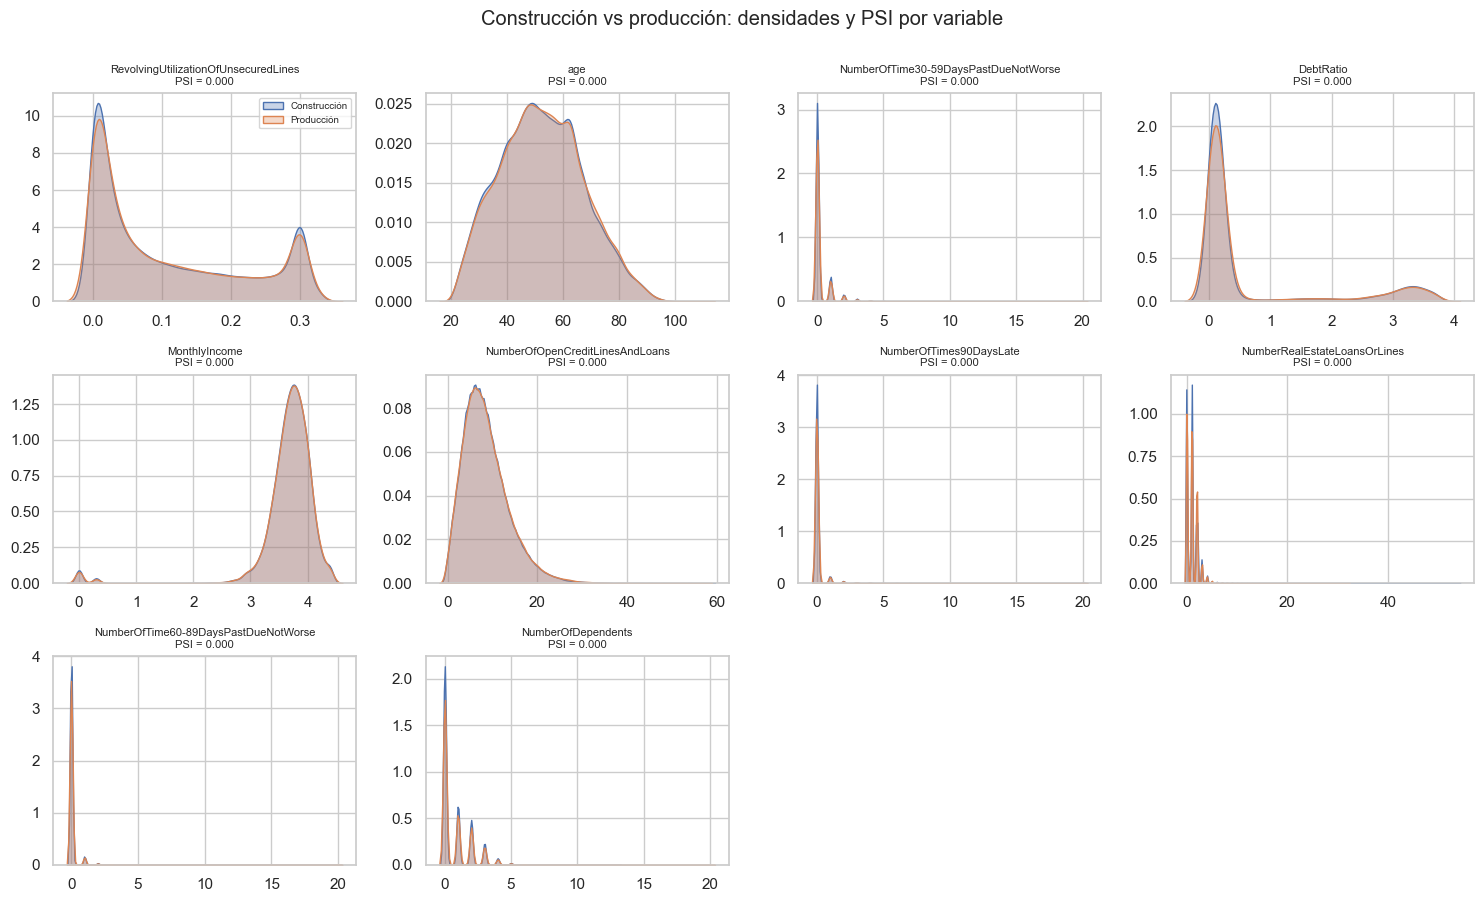

,DebtRatio,age,RevolvingUtilizationOfUnsecuredLines,NumberOfOpenCreditLinesAndLoans,MonthlyIncome,NumberOfDependents,NumberRealEstateLoansOrLines,IngresoAusente,NumberOfTime30-59DaysPastDueNotWorse,NumberOfTimes90DaysLate,NumberOfTime60-89DaysPastDueNotWorse,CodigoMoraEspecial
PSI,0.0005,0.0004,0.0002,0.0002,0.0001,0.0001,0.0001,0.0000,0.0000,0.0000,0.0000,0.0000


In [61]:
def psi(esperado, observado, bins=10):
    '''Population Stability Index entre dos muestras de una variable.'''
    cortes = np.nanquantile(esperado, np.linspace(0, 1, bins + 1))
    cortes[0], cortes[-1] = -np.inf, np.inf
    cortes = np.unique(cortes)
    e = np.histogram(esperado.dropna(), bins=cortes)[0] / esperado.notna().sum()
    o = np.histogram(observado.dropna(), bins=cortes)[0] / observado.notna().sum()
    e, o = np.clip(e, 1e-6, None), np.clip(o, 1e-6, None)
    return float(np.sum((o - e) * np.log(o / e)))

tabla_psi = pd.Series({c: psi(df_cons_l[c], df_prod_l[c]) for c in FEATURES},
                      name="PSI").sort_values(ascending=False)

fig, axes = plt.subplots(3, 4, figsize=(15, 9))
for ax, col in zip(axes.flat, FEATURES_BASE):
    a, b = df_cons_l[col].dropna(), df_prod_l[col].dropna()
    if col in LOG_VARS:
        a, b = np.log10(a + 1), np.log10(b + 1)
    sns.kdeplot(a, ax=ax, label="Construcción", fill=True, alpha=0.3)
    sns.kdeplot(b, ax=ax, label="Producción", fill=True, alpha=0.3)
    ax.set_title(f"{col}\nPSI = {tabla_psi[col]:.3f}", fontsize=8)
    ax.set_xlabel("")
    ax.set_ylabel("")
axes.flat[0].legend(fontsize=7)
for ax in axes.flat[len(FEATURES_BASE):]:
    ax.axis("off")
plt.suptitle("Construcción vs producción: densidades y PSI por variable", y=1.0)
plt.tight_layout()
plt.show()

tabla_psi.to_frame().T

## 5. Partición train / validación

Se reserva un 20% del histórico como conjunto de validación, estratificando por el target para mantener la proporción de impagos en ambas particiones. La validación cumple dos papeles: comparar modelos de forma honesta y, sobre todo, **optimizar el umbral de decisión por coste**, que es la pieza que determina la nota de producción. La búsqueda de hiperparámetros se hará con validación cruzada dentro del propio train, de modo que la validación quede intacta para esas dos tareas.

In [62]:
from sklearn.model_selection import train_test_split

X = df_cons_l[FEATURES]
y = df_cons_l[TARGET]

X_train, X_val, y_train, y_val = train_test_split(
    X, y, test_size=0.2, random_state=SEED, stratify=y)

print(f"Train:      {X_train.shape[0]:,} filas | tasa de impago {y_train.mean():.3%}")
print(f"Validación: {X_val.shape[0]:,} filas | tasa de impago {y_val.mean():.3%}")

Train:      83,999 filas | tasa de impago 6.683%
Validación: 21,000 filas | tasa de impago 6.686%


## 6. Modelos supervisados

### 6.1 Baseline: regresión logística

Se entrena primero un modelo lineal sencillo que sirve de listón mínimo. Cualquier modelo más complejo debe superarlo con claridad para justificar su menor interpretabilidad. Al no tolerar valores ausentes, la logística requiere imputación por la mediana y estandarizado, ambos encapsulados en un pipeline para que se apliquen de forma consistente.

In [63]:
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import roc_auc_score, average_precision_score

logit = Pipeline([
    ("imputador", SimpleImputer(strategy="median")),
    ("escalado", StandardScaler()),
    ("clf", LogisticRegression(max_iter=1000, random_state=SEED)),
])
logit.fit(X_train, y_train)
proba_logit = logit.predict_proba(X_val)[:, 1]

print(f"Regresión logística — AUC: {roc_auc_score(y_val, proba_logit):.4f} | "
      f"AP: {average_precision_score(y_val, proba_logit):.4f}")

Regresión logística — AUC: 0.8545 | AP: 0.3813


### 6.2 Modelo principal: Gradient Boosting

Como modelo principal se elige `HistGradientBoostingClassifier` por tres motivos: es el estado del arte en datos tabulares de este tamaño, **gestiona los valores ausentes de forma nativa** (aprende hacia qué rama enviar los NaN, aprovechando que la ausencia de ingreso es informativa) y entrena rápido sobre 100.000 filas. Se ajustan los hiperparámetros con búsqueda aleatoria y validación cruzada de 3 particiones optimizando el AUC, que mide la capacidad de ordenación del score con independencia del umbral (el umbral se optimizará después, por coste, para cada escenario).

In [64]:
from sklearn.ensemble import HistGradientBoostingClassifier
from sklearn.model_selection import RandomizedSearchCV

param_dist = {
    "learning_rate": [0.03, 0.05, 0.1],
    "max_leaf_nodes": [15, 31, 63],
    "min_samples_leaf": [20, 50, 100],
    "l2_regularization": [0.0, 0.1, 1.0],
    "max_depth": [None, 4, 6],
}

base = HistGradientBoostingClassifier(random_state=SEED, max_iter=500,
                                      early_stopping=True, validation_fraction=0.15)
busqueda = RandomizedSearchCV(base, param_dist, n_iter=15, scoring="roc_auc",
                              cv=3, random_state=SEED, n_jobs=-1)
busqueda.fit(X_train, y_train)

modelo = busqueda.best_estimator_
print("Mejores hiperparámetros:", busqueda.best_params_)
print(f"AUC medio en validación cruzada: {busqueda.best_score_:.4f}")

Mejores hiperparámetros: {'min_samples_leaf': 50, 'max_leaf_nodes': 31, 'max_depth': 4, 'learning_rate': 0.03, 'l2_regularization': 1.0}
AUC medio en validación cruzada: 0.8639


Se evalúa el modelo sobre la validación y se representa la evolución de la pérdida (log-loss) durante el entrenamiento, tanto en train como en la partición interna que usa la parada temprana. Esta curva es el diagnóstico de sobreajuste: mientras ambas bajan juntas el modelo sigue aprendiendo patrón general; si la de train siguiera cayendo con la de validación estancada o subiendo, se estaría memorizando ruido. La parada temprana corta el entrenamiento justo cuando la curva de validación deja de mejorar.

Gradient Boosting — AUC: 0.8699 | AP: 0.4035
Iteraciones efectivas tras parada temprana: 334


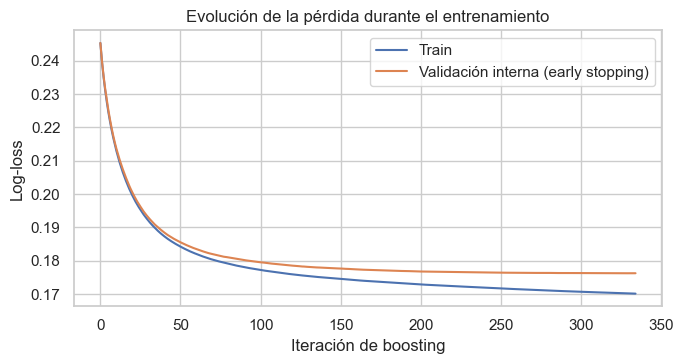

In [65]:
proba_val = modelo.predict_proba(X_val)[:, 1]
print(f"Gradient Boosting — AUC: {roc_auc_score(y_val, proba_val):.4f} | "
      f"AP: {average_precision_score(y_val, proba_val):.4f}")
print(f"Iteraciones efectivas tras parada temprana: {modelo.n_iter_}")

fig, ax = plt.subplots(figsize=(7, 3.8))
ax.plot(-np.array(modelo.train_score_), label="Train")
ax.plot(-np.array(modelo.validation_score_), label="Validación interna (early stopping)")
ax.set_xlabel("Iteración de boosting")
ax.set_ylabel("Log-loss")
ax.set_title("Evolución de la pérdida durante el entrenamiento")
ax.legend()
plt.tight_layout()
plt.show()

### 6.3 Curvas ROC y Precision-Recall

Se comparan ambos modelos con las dos curvas complementarias. La ROC resume la capacidad de ordenación global; la Precision-Recall es más exigente con clases desbalanceadas porque se centra en la clase minoritaria (los impagos). El Gradient Boosting domina a la logística en todo el rango de ambas curvas, con una mejora clara en AUC y en precisión media (AP), lo que justifica adoptarlo como modelo de decisión.

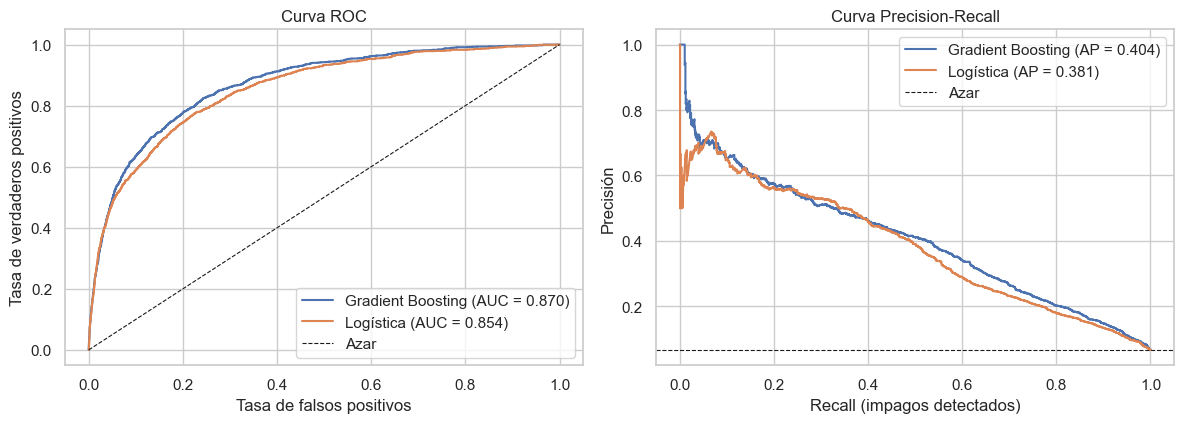

In [66]:
from sklearn.metrics import roc_curve, precision_recall_curve

fpr_gb, tpr_gb, _ = roc_curve(y_val, proba_val)
fpr_lg, tpr_lg, _ = roc_curve(y_val, proba_logit)
prec_gb, rec_gb, _ = precision_recall_curve(y_val, proba_val)
prec_lg, rec_lg, _ = precision_recall_curve(y_val, proba_logit)

fig, axes = plt.subplots(1, 2, figsize=(12, 4.4))
axes[0].plot(fpr_gb, tpr_gb,
             label=f"Gradient Boosting (AUC = {roc_auc_score(y_val, proba_val):.3f})")
axes[0].plot(fpr_lg, tpr_lg,
             label=f"Logística (AUC = {roc_auc_score(y_val, proba_logit):.3f})")
axes[0].plot([0, 1], [0, 1], "k--", lw=0.8, label="Azar")
axes[0].set_xlabel("Tasa de falsos positivos")
axes[0].set_ylabel("Tasa de verdaderos positivos")
axes[0].set_title("Curva ROC")
axes[0].legend()

axes[1].plot(rec_gb, prec_gb,
             label=f"Gradient Boosting (AP = {average_precision_score(y_val, proba_val):.3f})")
axes[1].plot(rec_lg, prec_lg,
             label=f"Logística (AP = {average_precision_score(y_val, proba_logit):.3f})")
axes[1].axhline(y_val.mean(), color="k", ls="--", lw=0.8, label="Azar")
axes[1].set_xlabel("Recall (impagos detectados)")
axes[1].set_ylabel("Precisión")
axes[1].set_title("Curva Precision-Recall")
axes[1].legend()
plt.tight_layout()
plt.show()

### 6.4 Calibración de las probabilidades

La optimización del umbral por coste solo tiene sentido si las probabilidades del modelo significan lo que dicen (que entre los clientes con score 0.3 impague aproximadamente el 30%). Se comprueba con la curva de calibración por cuantiles: los puntos se sitúan muy cerca de la diagonal, de modo que el score puede tratarse directamente como una probabilidad de impago sin recalibración adicional. El histograma por clase muestra además el comportamiento esperado: la gran mayoría de clientes buenos concentrados en scores bajos y los impagos desplazados hacia scores altos, aunque con solapamiento (coherente con lo visto en el PCA).

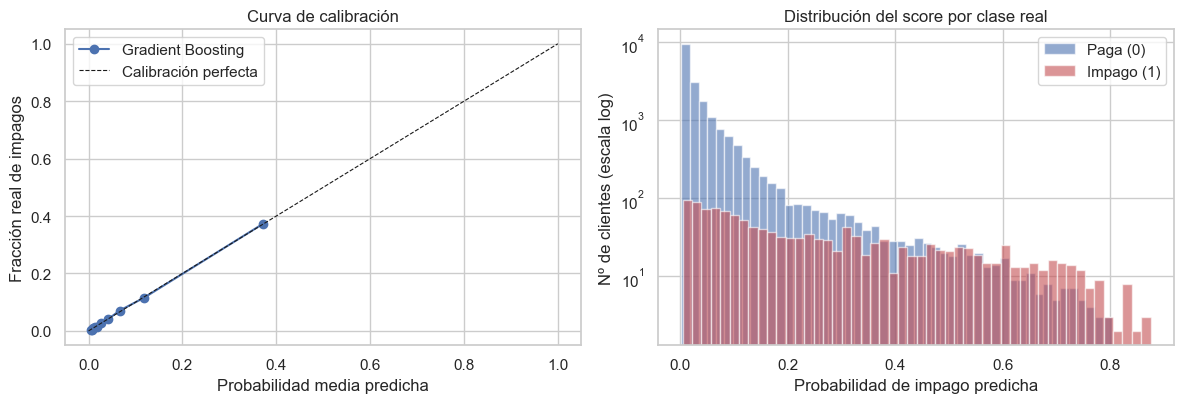

In [67]:
from sklearn.calibration import calibration_curve

frac_pos, media_pred = calibration_curve(y_val, proba_val, n_bins=10, strategy="quantile")

fig, axes = plt.subplots(1, 2, figsize=(12, 4.2))
axes[0].plot(media_pred, frac_pos, marker="o", label="Gradient Boosting")
axes[0].plot([0, 1], [0, 1], "k--", lw=0.8, label="Calibración perfecta")
axes[0].set_xlabel("Probabilidad media predicha")
axes[0].set_ylabel("Fracción real de impagos")
axes[0].set_title("Curva de calibración")
axes[0].legend()

axes[1].hist(proba_val[y_val == 0], bins=50, alpha=0.6, label="Paga (0)",
             color="#4c72b0", log=True)
axes[1].hist(proba_val[y_val == 1], bins=50, alpha=0.6, label="Impago (1)",
             color="#c44e52", log=True)
axes[1].set_xlabel("Probabilidad de impago predicha")
axes[1].set_ylabel("Nº de clientes (escala log)")
axes[1].set_title("Distribución del score por clase real")
axes[1].legend()
plt.tight_layout()
plt.show()

### 6.5 Lift y captura por deciles

Se cierra la evaluación con el análisis por deciles de score, el formato en que se suele comunicar un modelo de riesgo al negocio. El lift indica cuántas veces más impagos hay en cada decil respecto a la media; la curva de captura, qué porcentaje del total de impagos se concentra en los deciles de mayor riesgo. Que el primer decil concentre un lift muy alto y que con los dos o tres primeros deciles se capture la mayoría de los impagos confirma que el score ordena bien el riesgo y que denegar solo a una fracción pequeña de solicitantes ya elimina gran parte de las pérdidas.

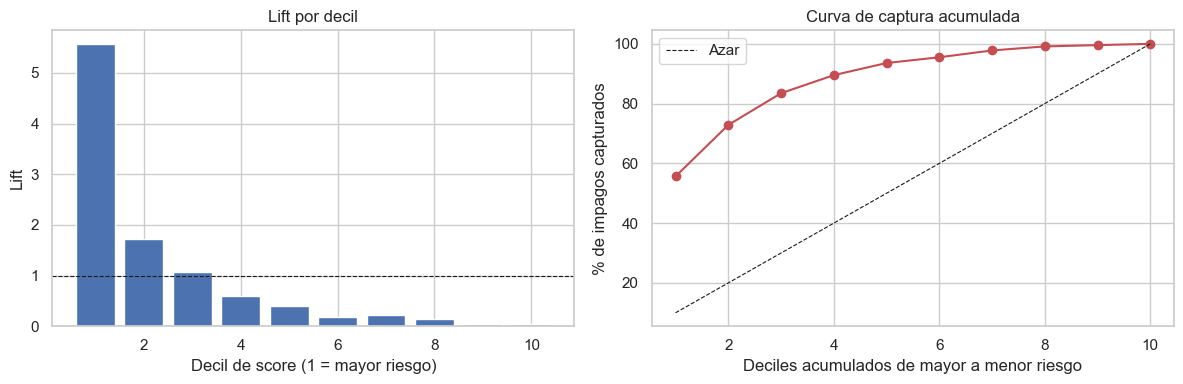

In [68]:
df_lift = pd.DataFrame({"y": y_val.values, "score": proba_val})
df_lift["decil"] = pd.qcut(df_lift["score"].rank(method="first"), 10, labels=False)
por_decil = (df_lift.groupby("decil")["y"].agg(["mean", "sum", "count"])
             .iloc[::-1].reset_index(drop=True))
por_decil["captura_acum"] = por_decil["sum"].cumsum() / por_decil["sum"].sum()
por_decil["lift"] = por_decil["mean"] / df_lift["y"].mean()

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].bar(range(1, 11), por_decil["lift"], color="#4c72b0")
axes[0].axhline(1, color="k", ls="--", lw=0.8)
axes[0].set_xlabel("Decil de score (1 = mayor riesgo)")
axes[0].set_ylabel("Lift")
axes[0].set_title("Lift por decil")

axes[1].plot(range(1, 11), 100 * por_decil["captura_acum"], marker="o", color="#c44e52")
axes[1].plot([1, 10], [10, 100], "k--", lw=0.8, label="Azar")
axes[1].set_xlabel("Deciles acumulados de mayor a menor riesgo")
axes[1].set_ylabel("% de impagos capturados")
axes[1].set_title("Curva de captura acumulada")
axes[1].legend()
plt.tight_layout()
plt.show()

## 7. Optimización del umbral de decisión por coste

El modelo produce probabilidades; la decisión (conceder/denegar) requiere un umbral, y el umbral óptimo depende de los costes. La teoría de la decisión da el valor de referencia: se deniega cuando el coste esperado de conceder supera al de denegar, es decir cuando `p > c_FP / (c_FP + c_FN)`. Eso da un umbral teórico de **0.5** para el escenario 1 y de **1/11 ≈ 0.091** para el escenario 2. Como la calibración nunca es perfecta, se contrasta el valor teórico con un barrido empírico del coste medio en validación sobre todo el rango de umbrales. La cercanía entre ambos valores es a la vez una confirmación de la buena calibración del modelo y una garantía de que el umbral elegido no es un artefacto de la muestra de validación.

In [69]:
def coste_medio(y_real, proba, umbral, coste_fp, coste_fn):
    pred = (proba >= umbral).astype(int)
    fp = int(((pred == 1) & (y_real == 0)).sum())
    fn = int(((pred == 0) & (y_real == 1)).sum())
    return (coste_fp * fp + coste_fn * fn) / len(y_real)

ESCENARIOS = {
    "Escenario 1 (FP=1, FN=1)": (1, 1),
    "Escenario 2 (FP=1, FN=10)": (1, 10),
}

umbrales = np.linspace(0.005, 0.995, 199)
curvas, umbral_opt = {}, {}
for nombre, (cfp, cfn) in ESCENARIOS.items():
    costes = np.array([coste_medio(y_val.values, proba_val, u, cfp, cfn) for u in umbrales])
    curvas[nombre] = costes
    umbral_opt[nombre] = float(umbrales[np.argmin(costes)])
    print(f"{nombre}: umbral teórico = {cfp/(cfp+cfn):.3f} | "
          f"umbral óptimo empírico = {umbral_opt[nombre]:.3f} | "
          f"coste medio mínimo en validación = {costes.min():.4f}")

Escenario 1 (FP=1, FN=1): umbral teórico = 0.500 | umbral óptimo empírico = 0.580 | coste medio mínimo en validación = 0.0631
Escenario 2 (FP=1, FN=10): umbral teórico = 0.091 | umbral óptimo empírico = 0.100 | coste medio mínimo en validación = 0.3273


Se representa el coste medio en función del umbral para ambos escenarios, junto con la traducción del umbral a política de negocio (% de solicitudes denegadas). La lectura es directa: con costes simétricos el mínimo es plano y se sitúa en torno a 0.5 (compensa denegar a muy pocos, solo a los casi seguros impagos); con el impago costando 10 veces más, el mínimo se desplaza a umbrales bajos y la política óptima pasa a ser mucho más conservadora, denegando a una fracción considerablemente mayor de solicitantes. La curva del escenario 2 es además mucho más empinada a la izquierda del óptimo: quedarse corto denegando sale caro.

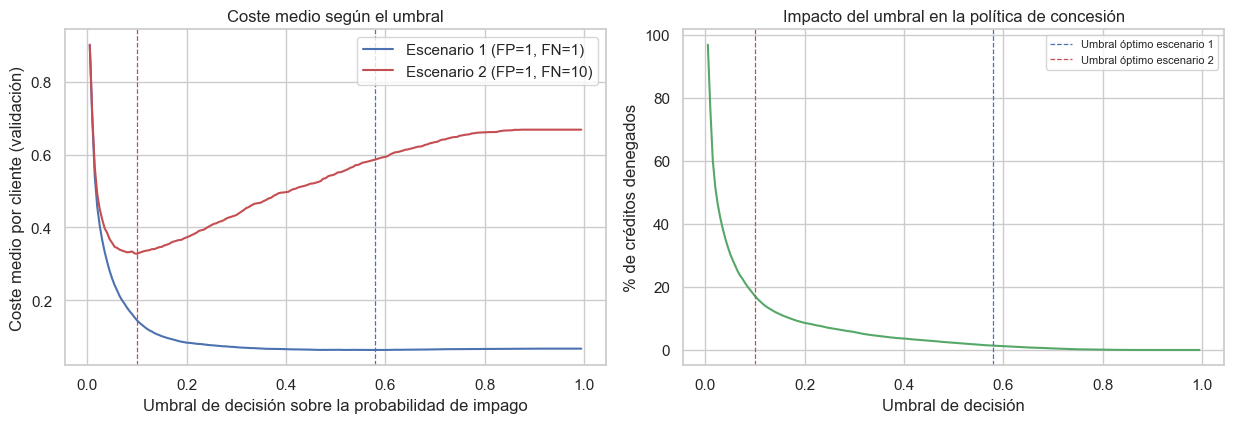

In [70]:
colores = {"Escenario 1 (FP=1, FN=1)": "#4c72b0", "Escenario 2 (FP=1, FN=10)": "#c44e52"}

fig, axes = plt.subplots(1, 2, figsize=(12.5, 4.4))
for nombre, costes in curvas.items():
    axes[0].plot(umbrales, costes, label=nombre, color=colores[nombre])
    axes[0].axvline(umbral_opt[nombre], color=colores[nombre], ls="--", lw=0.9)
axes[0].set_xlabel("Umbral de decisión sobre la probabilidad de impago")
axes[0].set_ylabel("Coste medio por cliente (validación)")
axes[0].set_title("Coste medio según el umbral")
axes[0].legend()

pct_denegados = [100 * (proba_val >= u).mean() for u in umbrales]
axes[1].plot(umbrales, pct_denegados, color="#55a868")
for nombre in ESCENARIOS:
    axes[1].axvline(umbral_opt[nombre], color=colores[nombre], ls="--", lw=0.9,
                    label=f"Umbral óptimo {nombre.split('(')[0].strip().lower()}")
axes[1].set_xlabel("Umbral de decisión")
axes[1].set_ylabel("% de créditos denegados")
axes[1].set_title("Impacto del umbral en la política de concesión")
axes[1].legend(fontsize=8)
plt.tight_layout()
plt.show()

Se materializan las dos políticas con sus matrices de confusión en validación y una tabla resumen. Las dos matrices cuentan la misma historia desde ángulos distintos: en el escenario 1 se tolera dejar pasar bastantes impagos con tal de no molestar a clientes buenos, mientras que en el escenario 2 se dispara el recall de impagos a costa de denegar también a un bloque de buenos clientes, porque cada impago no detectado cuesta como diez denegaciones injustas.

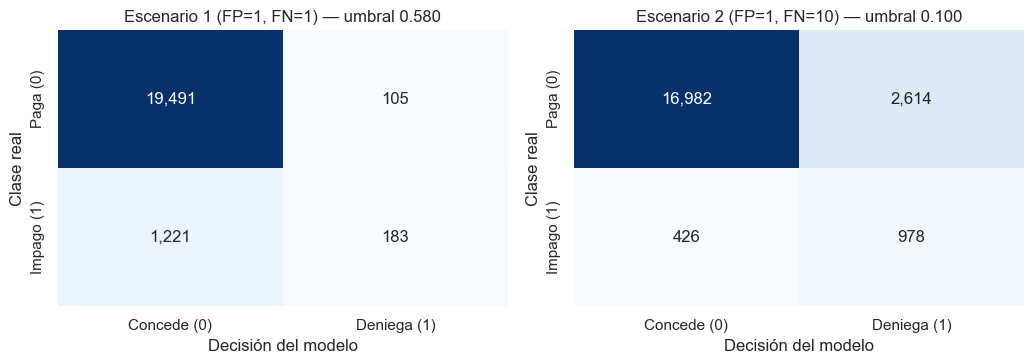

,Umbral,Coste medio (validación),% denegados,Recall de impagos,Precisión al denegar
Escenario,,,,,
"Escenario 1 (FP=1, FN=1)",0.5800,0.0631,1.3700,0.1300,0.6350
"Escenario 2 (FP=1, FN=10)",0.1000,0.3273,17.1000,0.6970,0.2720


In [71]:
from sklearn.metrics import confusion_matrix

fig, axes = plt.subplots(1, 2, figsize=(10.5, 3.8))
resumen_umbral = []
for ax, (nombre, (cfp, cfn)) in zip(axes, ESCENARIOS.items()):
    u = umbral_opt[nombre]
    pred = (proba_val >= u).astype(int)
    cm = confusion_matrix(y_val, pred)
    sns.heatmap(cm, annot=True, fmt=",", cmap="Blues", cbar=False, ax=ax,
                xticklabels=["Concede (0)", "Deniega (1)"],
                yticklabels=["Paga (0)", "Impago (1)"])
    ax.set_title(f"{nombre} — umbral {u:.3f}")
    ax.set_xlabel("Decisión del modelo")
    ax.set_ylabel("Clase real")
    resumen_umbral.append({
        "Escenario": nombre,
        "Umbral": round(u, 3),
        "Coste medio (validación)": round(coste_medio(y_val.values, proba_val, u, cfp, cfn), 4),
        "% denegados": round(100 * pred.mean(), 2),
        "Recall de impagos": round(cm[1, 1] / cm[1].sum(), 3),
        "Precisión al denegar": round(cm[1, 1] / max(cm[:, 1].sum(), 1), 3),
    })
plt.tight_layout()
plt.show()

pd.DataFrame(resumen_umbral).set_index("Escenario")

## 8. Predicciones para producción

Se aplica el modelo al fichero de producción (ya limpiado con los mismos topes que construcción) y se generan los dos ficheros de entrega, cada uno con la columna `prediccion` (0 = conceder, 1 = denegar) en el mismo orden que `cs_produccion.csv`. Se verifica que ambos contienen exactamente 45.000 decisiones y que, como cabía esperar, el escenario 2 deniega a bastantes más clientes por su umbral más bajo. La proporción de denegaciones en producción resulta coherente con la observada en validación, señal adicional (junto al PSI) de que ambas poblaciones se comportan igual.

In [72]:
proba_prod = modelo.predict_proba(df_prod_l[FEATURES])[:, 1]

pred_prod = {}
for nombre in ESCENARIOS:
    pred_prod[nombre] = (proba_prod >= umbral_opt[nombre]).astype(int)

pd.DataFrame({"prediccion": pred_prod["Escenario 1 (FP=1, FN=1)"]}).to_csv(
    "data/cs_produccion1.csv", index=False)
pd.DataFrame({"prediccion": pred_prod["Escenario 2 (FP=1, FN=10)"]}).to_csv(
    "data/cs_produccion2.csv", index=False)

for fichero, nombre in [("data/cs_produccion1.csv", "Escenario 1 (FP=1, FN=1)"),
                        ("data/cs_produccion2.csv", "Escenario 2 (FP=1, FN=10)")]:
    p = pred_prod[nombre]
    print(f"{fichero}: {len(p):,} predicciones | {p.mean():.2%} denegaciones "
          f"(validación: {100*(proba_val >= umbral_opt[nombre]).mean():.2f}%)")

data/cs_produccion1.csv: 45,000 predicciones | 1.40% denegaciones (validación: 1.37%)
data/cs_produccion2.csv: 45,000 predicciones | 16.85% denegaciones (validación: 17.10%)


## 9. Auditoría del modelo con técnicas XAI

Un modelo de concesión de crédito no puede ser una caja negra: la normativa y la propia relación con el cliente exigen poder explicar cada denegación. Se audita el modelo con cuatro técnicas complementarias: un **modelo surrogado** de reglas (visión global simplificada), **SHAP** global y local (atribución exacta de cada decisión), **contrafactuales** (qué tendría que cambiar para que la decisión cambiara) y **dependencia parcial e importancia por permutación** (contraste independiente de lo anterior). El foco se pone en la política del escenario 2, que es la más restrictiva y por tanto la que más denegaciones tendrá que justificar.

### 9.1 Modelo surrogado con reglas

Se entrena un árbol de decisión poco profundo para que **imite las decisiones del Gradient Boosting** (no la realidad, sino lo que el modelo decide). El árbol no sustituye al modelo: es su "traducción" a reglas legibles. La métrica clave es la **fidelidad**: el porcentaje de decisiones del modelo original que el surrogado reproduce. Con una fidelidad alta, las reglas del árbol son un resumen fiel de la política global del modelo.

In [73]:
from sklearn.tree import DecisionTreeClassifier, plot_tree, export_text

ESC2 = "Escenario 2 (FP=1, FN=10)"
ESC1 = "Escenario 1 (FP=1, FN=1)"

decision_gb = (proba_val >= umbral_opt[ESC2]).astype(int)

imputador_surr = SimpleImputer(strategy="median").fit(X_train)
X_val_imp = pd.DataFrame(imputador_surr.transform(X_val), columns=FEATURES)

surrogado = DecisionTreeClassifier(max_depth=3, random_state=SEED)
surrogado.fit(X_val_imp, decision_gb)

fidelidad = surrogado.score(X_val_imp, decision_gb)
decision_gb1 = (proba_val >= umbral_opt[ESC1]).astype(int)
surrogado1 = DecisionTreeClassifier(max_depth=3, random_state=SEED).fit(X_val_imp, decision_gb1)

print(f"Fidelidad del surrogado (escenario 2): {fidelidad:.2%}")
print(f"Fidelidad del surrogado (escenario 1): {surrogado1.score(X_val_imp, decision_gb1):.2%}")

Fidelidad del surrogado (escenario 2): 92.77%
Fidelidad del surrogado (escenario 1): 99.28%


Se visualiza el árbol surrogado del escenario 2. Cada nodo muestra la condición de corte y la proporción de clientes que sigue cada rama; el color de cada hoja indica su clase mayoritaria (conceder o denegar). El árbol revela la lógica esencial de la política aprendida: el historial de morosidad y la utilización de las líneas de crédito son las variables que estructuran las decisiones, en línea con lo que anticipaba el EDA.

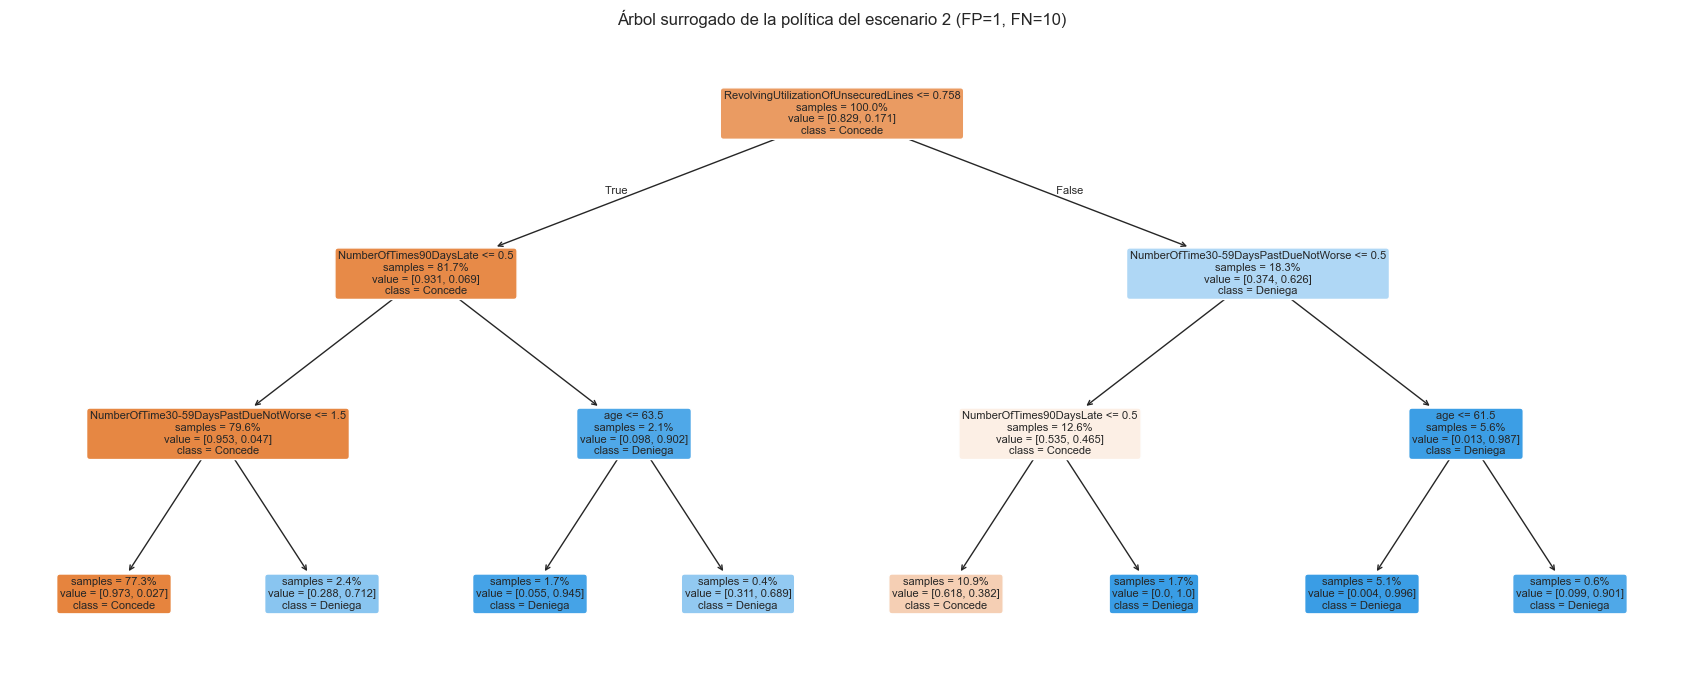

In [74]:
fig, ax = plt.subplots(figsize=(17, 7))
plot_tree(surrogado, feature_names=FEATURES, class_names=["Concede", "Deniega"],
          filled=True, rounded=True, fontsize=8, impurity=False, proportion=True, ax=ax)
ax.set_title("Árbol surrogado de la política del escenario 2 (FP=1, FN=10)")
plt.tight_layout()
plt.show()

Se extraen las mismas reglas en formato texto, que es como se comunicarían a un comité de riesgos o se incluirían en documentación regulatoria. Cada camino de la raíz a una hoja es una regla del tipo "si se cumplen estas condiciones, la política del modelo es conceder/denegar".

In [75]:
print(export_text(surrogado, feature_names=FEATURES, decimals=3, show_weights=True))

|--- RevolvingUtilizationOfUnsecuredLines <= 0.758
|   |--- NumberOfTimes90DaysLate <= 0.500
|   |   |--- NumberOfTime30-59DaysPastDueNotWorse <= 1.500
|   |   |   |--- weights: [15786.000, 437.000] class: 0
|   |   |--- NumberOfTime30-59DaysPastDueNotWorse >  1.500
|   |   |   |--- weights: [144.000, 356.000] class: 1
|   |--- NumberOfTimes90DaysLate >  0.500
|   |   |--- age <= 63.500
|   |   |   |--- weights: [20.000, 343.000] class: 1
|   |   |--- age >  63.500
|   |   |   |--- weights: [23.000, 51.000] class: 1
|--- RevolvingUtilizationOfUnsecuredLines >  0.758
|   |--- NumberOfTime30-59DaysPastDueNotWorse <= 0.500
|   |   |--- NumberOfTimes90DaysLate <= 0.500
|   |   |   |--- weights: [1419.000, 878.000] class: 0
|   |   |--- NumberOfTimes90DaysLate >  0.500
|   |   |   |--- weights: [0.000, 357.000] class: 1
|   |--- NumberOfTime30-59DaysPastDueNotWorse >  0.500
|   |   |--- age <= 61.500
|   |   |   |--- weights: [4.000, 1061.000] class: 1
|   |   |--- age >  61.500
|   |   |  

### 9.2 SHAP global

Se calculan los valores SHAP del modelo sobre una muestra de validación. SHAP reparte la predicción de cada cliente entre las variables de forma exacta y con garantías teóricas (valores de Shapley), lo que lo convierte en el estándar de atribución para modelos de árboles. El gráfico *beeswarm* resume el comportamiento global: cada punto es un cliente, el color indica si su valor en esa variable es alto o bajo, y la posición horizontal indica si esa variable empuja su predicción hacia el impago (derecha) o hacia el pago (izquierda). Se comprueba la coherencia con todo lo anterior: alta utilización de crédito y retrasos previos empujan con fuerza hacia la denegación; edad alta e historial limpio, hacia la concesión.

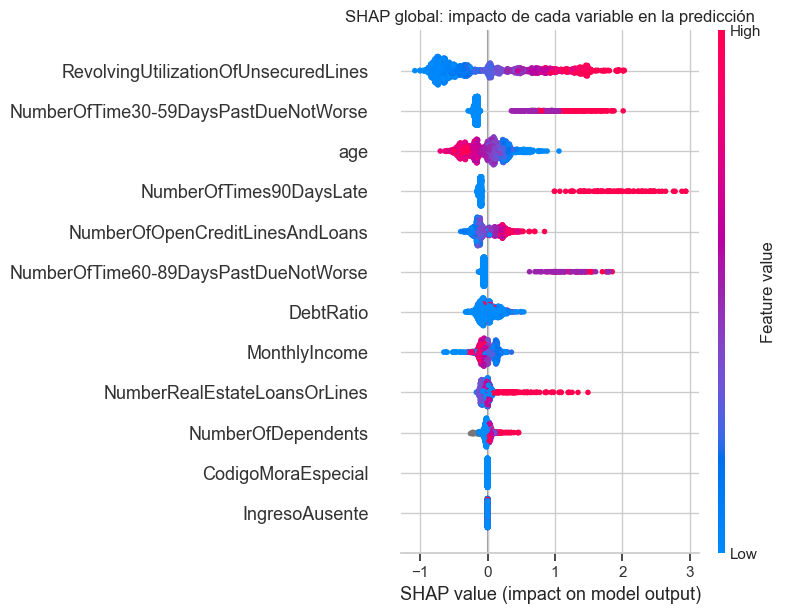

In [76]:
import shap

muestra = X_val.sample(2000, random_state=SEED)
explainer = shap.TreeExplainer(modelo)
shap_exp = explainer(muestra)

shap.plots.beeswarm(shap_exp, max_display=12, show=False)
plt.title("SHAP global: impacto de cada variable en la predicción")
plt.tight_layout()
plt.show()

Se complementa con el ranking de importancia media (valor absoluto medio de SHAP) y con los gráficos de dependencia de las variables más influyentes, que muestran la **forma** de cada efecto y no solo su magnitud. Se observan efectos claramente no lineales, con saltos bruscos: superar cierto nivel de utilización del crédito o registrar el primer retraso grave cambia la contribución de golpe, un comportamiento tipo "regla" que un modelo lineal no podría capturar y que explica la ventaja del boosting sobre la logística.

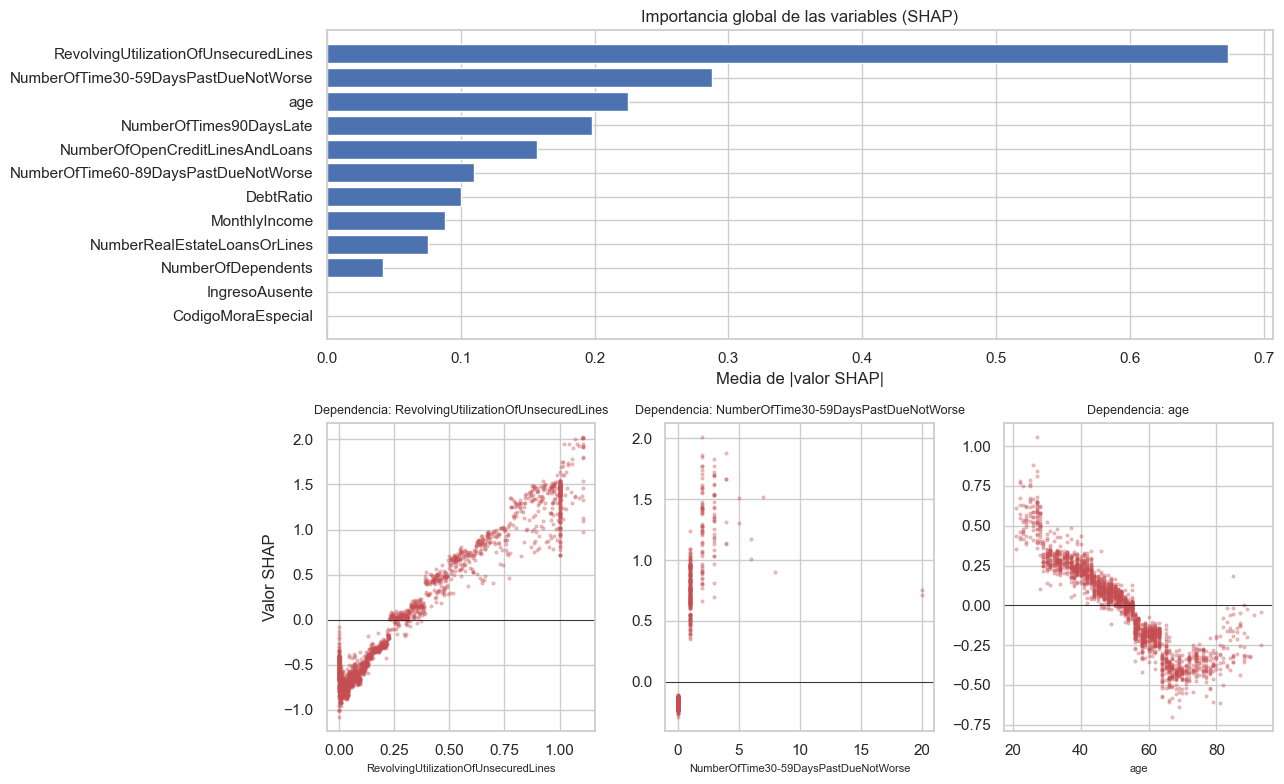

In [77]:
importancia_shap = pd.Series(np.abs(shap_exp.values).mean(axis=0),
                             index=FEATURES).sort_values(ascending=False)

fig = plt.figure(figsize=(13, 8))
gs = fig.add_gridspec(2, 3)

ax0 = fig.add_subplot(gs[0, :])
ax0.barh(importancia_shap.index[::-1], importancia_shap.values[::-1], color="#4c72b0")
ax0.set_xlabel("Media de |valor SHAP|")
ax0.set_title("Importancia global de las variables (SHAP)")

top3 = list(importancia_shap.index[:3])
for k, var in enumerate(top3):
    ax = fig.add_subplot(gs[1, k])
    j = FEATURES.index(var)
    ax.scatter(muestra[var], shap_exp.values[:, j], s=4, alpha=0.3, color="#c44e52")
    ax.axhline(0, color="k", lw=0.6)
    ax.set_xlabel(var, fontsize=8)
    ax.set_ylabel("Valor SHAP" if k == 0 else "")
    ax.set_title(f"Dependencia: {var}", fontsize=9)
plt.tight_layout()
plt.show()

### 9.3 SHAP local: explicación de decisiones individuales

Se explican casos concretos con gráficos *waterfall*, que descomponen la predicción de un cliente partiendo del valor base (la media de la población) y sumando la contribución de cada variable hasta llegar a su score final. Se seleccionan tres perfiles representativos: el cliente con mayor probabilidad de impago (denegación clara), uno justo por encima del umbral del escenario 2 (denegación ajustada, el caso más delicado de justificar) y uno de concesión clara. Estos gráficos son la base de la explicación individual que se le daría a cada cliente.


=== Denegación clara — probabilidad de impago: 0.807 (umbral escenario 2: 0.100) ===


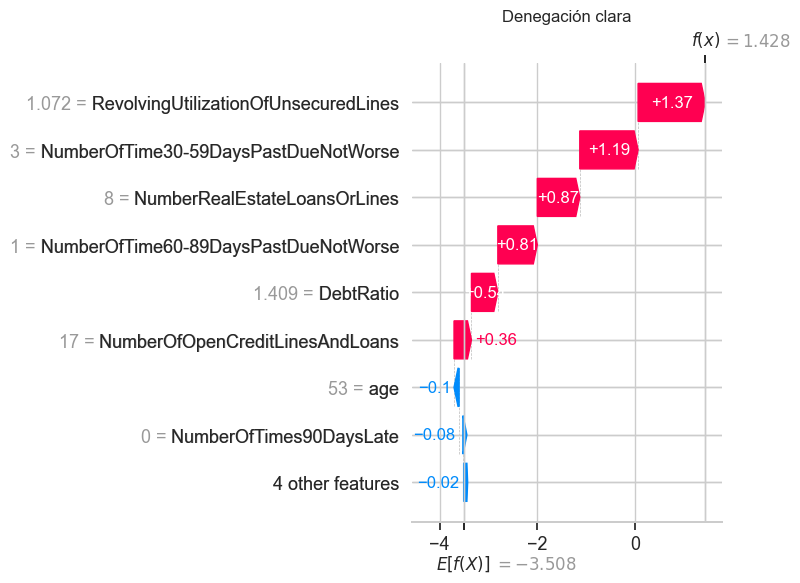


=== Denegación ajustada (borde del umbral) — probabilidad de impago: 0.107 (umbral escenario 2: 0.100) ===


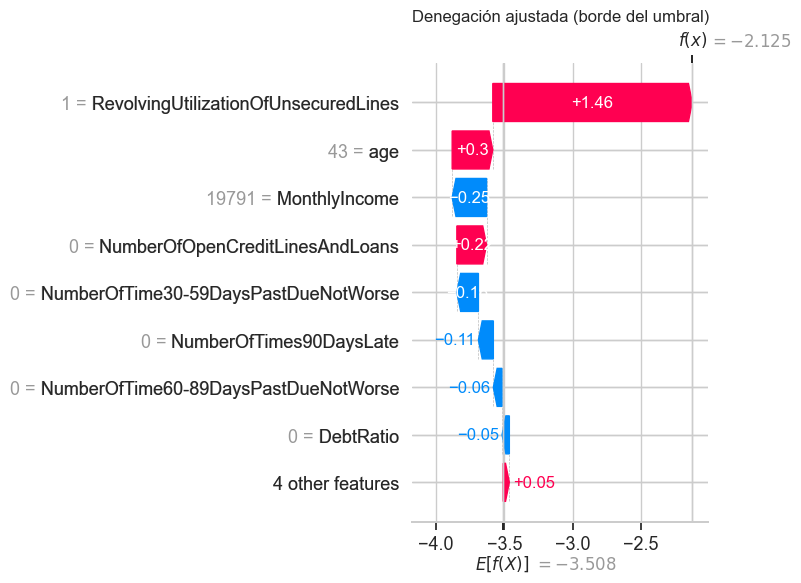


=== Concesión clara — probabilidad de impago: 0.002 (umbral escenario 2: 0.100) ===


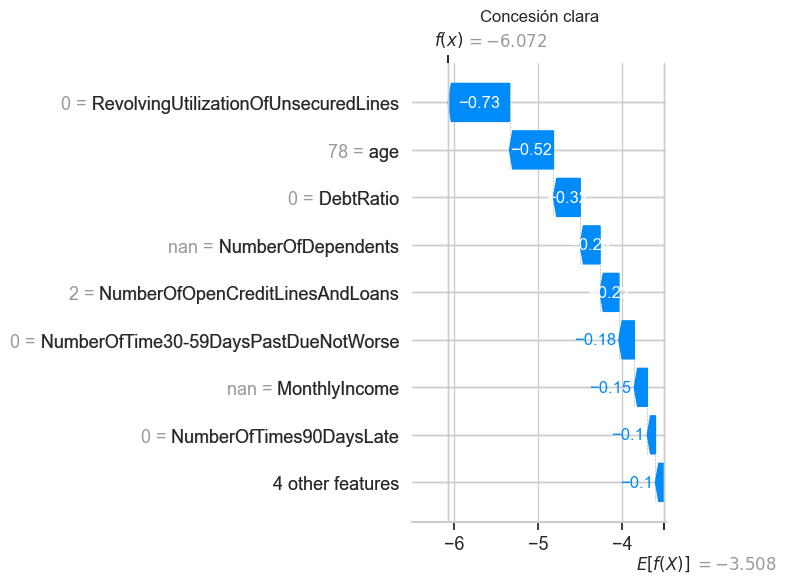

In [78]:
proba_muestra = modelo.predict_proba(muestra)[:, 1]
u2 = umbral_opt[ESC2]

idx_denegado = int(np.argmax(proba_muestra))
candidatos_borde = np.where((proba_muestra >= u2) & (proba_muestra <= u2 + 0.03))[0]
idx_borde = int(candidatos_borde[0]) if len(candidatos_borde) else int(np.argmin(np.abs(proba_muestra - u2)))
idx_concedido = int(np.argmin(proba_muestra))

casos = [("Denegación clara", idx_denegado),
         ("Denegación ajustada (borde del umbral)", idx_borde),
         ("Concesión clara", idx_concedido)]

for titulo, idx in casos:
    print(f"\n=== {titulo} — probabilidad de impago: {proba_muestra[idx]:.3f} "
          f"(umbral escenario 2: {u2:.3f}) ===")
    shap.plots.waterfall(shap_exp[idx], max_display=9, show=False)
    plt.title(titulo)
    plt.tight_layout()
    plt.show()

### 9.4 Contrafactuales: ¿qué tendría que cambiar para que la decisión cambiara?

La explicación más útil para un cliente denegado no es solo "por qué", sino "**qué puede hacer**". Se generan explicaciones contrafactuales con DiCE: perturbaciones mínimas de los datos del cliente que harían que el modelo pasara de denegar a conceder. Dos decisiones de diseño importantes:

- Solo se permite variar las variables **accionables** por el cliente (utilización del crédito, ratio de deuda, ingreso y número de líneas abiertas). No tendría sentido sugerir "ser 20 años mayor" ni se puede reescribir el historial de morosidad.
- Se exige que el contrafactual no solo cruce el 0.5 genérico, sino que baje **por debajo del umbral real de la política del escenario 2**, que es el que decide.

Se analizan varios clientes denegados de ambas clases reales: impagos verdaderos (la denegación acertó) y también clientes que en realidad habrían pagado (falsos positivos, los más importantes de cara a la explicabilidad, porque son quienes sufren una denegación injusta). Se seleccionan denegaciones **moderadas** (probabilidad de impago entre el umbral y 0.20), que son los casos frontera donde una mejora accionable puede revertir la decisión de forma realista; en los perfiles con morosidad grave ningún cambio accionable revierte la denegación, y cuando eso ocurre el sistema lo hace constar explícitamente en lugar de inventar recomendaciones vacías.

In [79]:
import dice_ml

datos_dice = X_val.dropna().copy()
y_dice = y_val.loc[datos_dice.index]
datos_dice[TARGET] = y_dice.values

d = dice_ml.Data(dataframe=datos_dice, continuous_features=FEATURES, outcome_name=TARGET)
m = dice_ml.Model(model=modelo, backend="sklearn")
generador_cf = dice_ml.Dice(d, m, method="random")

ACCIONABLES = ["RevolvingUtilizationOfUnsecuredLines", "DebtRatio",
               "MonthlyIncome", "NumberOfOpenCreditLinesAndLoans"]

proba_dice = modelo.predict_proba(datos_dice[FEATURES])[:, 1]
frontera = (proba_dice >= u2) & (proba_dice <= 0.20)
denegados = datos_dice[frontera]
y_denegados = y_dice[frontera]

# Dos denegados que realmente impagaron y dos que realmente habrían pagado
ejemplos = pd.concat([denegados[y_denegados == 1].head(2),
                      denegados[y_denegados == 0].head(2)])
print("Clientes denegados seleccionados (clases reales:",
      list(y_denegados.loc[ejemplos.index].values), ")")
ejemplos[FEATURES]

Clientes denegados seleccionados (clases reales: [np.int64(1), np.int64(1), np.int64(0), np.int64(0)] )


,RevolvingUtilizationOfUnsecuredLines,age,NumberOfTime30-59DaysPastDueNotWorse,DebtRatio,MonthlyIncome,NumberOfOpenCreditLinesAndLoans,NumberOfTimes90DaysLate,NumberRealEstateLoansOrLines,NumberOfTime60-89DaysPastDueNotWorse,NumberOfDependents,IngresoAusente,CodigoMoraEspecial
69402,1.0000,25,0,0.0384,1300.0000,6,0,0,0,0.0000,0,0
62274,1.0000,57,0,1.3669,9583.0000,9,0,5,0,0.0000,0,0
70799,0.0000,51,0,0.3101,5407.0000,8,1,3,0,0.0000,0,0
47521,1.0062,43,0,0.4339,4000.0000,5,0,2,0,0.0000,0,0


Se generan varios candidatos a contrafactual por cliente con dos salvaguardas que DiCE no aplica por sí solo:

- **Plausibilidad**: se restringe el rango permitido de cada variable a cambios realistas en la dirección correcta. La utilización del crédito, el ratio de deuda y el número de líneas abiertas solo pueden **bajar** respecto a la situación actual, y el ingreso solo puede **subir de forma moderada** (hasta un 30%). Sin esta restricción el generador puede proponer cambios matemáticamente válidos pero absurdos como recomendación.
- **Verificación**: cada candidato se comprueba contra el modelo real y solo se aceptan los que dejan la probabilidad de impago **por debajo del umbral de la política**, no del 0.5 genérico.

Para cada cliente denegado se muestran sus valores originales y hasta dos cambios validados que convertirían la denegación en concesión. El patrón es consistente con el análisis SHAP: la palanca principal es reducir la utilización de las líneas de crédito, seguida de la reducción de deuda y del número de líneas abiertas.

In [80]:
resultados_cf = {}
for i in range(len(ejemplos)):
    fila = ejemplos.iloc[[i]]
    x = fila.iloc[0]
    p_orig = modelo.predict_proba(fila[FEATURES])[0, 1]
    print(f"\n{'='*74}\nCliente denegado {i+1} (clase real: {int(y_denegados.loc[fila.index[0]])})"
          f" — probabilidad de impago: {p_orig:.3f} (umbral: {u2:.3f})")

    rango_plausible = {
        "RevolvingUtilizationOfUnsecuredLines": [0.0, float(x["RevolvingUtilizationOfUnsecuredLines"])],
        "DebtRatio": [0.0, float(x["DebtRatio"])],
        "MonthlyIncome": [float(x["MonthlyIncome"]), float(x["MonthlyIncome"]) * 1.3],
        "NumberOfOpenCreditLinesAndLoans": [0.0, float(x["NumberOfOpenCreditLinesAndLoans"])],
    }
    np.random.seed(SEED)
    cf = generador_cf.generate_counterfactuals(
        fila[FEATURES], total_CFs=10, desired_class=0,
        features_to_vary=ACCIONABLES, permitted_range=rango_plausible,
        stopping_threshold=float(1 - u2))

    candidatos = cf.cf_examples_list[0].final_cfs_df
    if candidatos is None or len(candidatos) == 0:
        print("  No se encontró ningún contrafactual accionable.")
        continue
    p_cfs = modelo.predict_proba(candidatos[FEATURES])[:, 1]
    validos = candidatos[p_cfs < u2].copy()
    validos["prob. impago"] = p_cfs[p_cfs < u2]
    validos = validos.sort_values("prob. impago")
    if len(validos) == 0:
        print("  Ningún candidato validado: la denegación no se revierte solo con")
        print("  cambios accionables (pesa demasiado el historial de morosidad).")
        continue
    resultados_cf[i] = validos

    filas = [pd.concat([x[ACCIONABLES],
                        pd.Series({"prob. impago": p_orig})]).rename("Situación actual")]
    for k, (_, fila_cf) in enumerate(validos.head(2).iterrows(), 1):
        filas.append(fila_cf[ACCIONABLES + ["prob. impago"]].astype(float)
                     .rename(f"Contrafactual {k}"))
    display(pd.DataFrame(filas).round(3))


Cliente denegado 1 (clase real: 1) — probabilidad de impago: 0.138 (umbral: 0.100)


100%|██████████| 1/1 [01:06<00:00, 66.46s/it]


,RevolvingUtilizationOfUnsecuredLines,DebtRatio,MonthlyIncome,NumberOfOpenCreditLinesAndLoans,prob. impago
Situación actual,1.0000,0.0380,1300.0000,6.0000,0.1380
Contrafactual 1,0.2770,0.0380,1405.5000,6.0000,0.0410
Contrafactual 2,0.3380,0.0380,1505.7000,6.0000,0.0460



Cliente denegado 2 (clase real: 1) — probabilidad de impago: 0.168 (umbral: 0.100)


100%|██████████| 1/1 [00:57<00:00, 57.66s/it]


...

100%|██████████| 1/1 [00:59<00:00, 59.57s/it]


,RevolvingUtilizationOfUnsecuredLines,DebtRatio,MonthlyIncome,NumberOfOpenCreditLinesAndLoans,prob. impago
Situación actual,0.0000,0.3100,5407.0000,8.0000,0.1130
Contrafactual 1,0.0000,0.0000,5407.0000,5.0000,0.0700
Contrafactual 2,0.0000,0.1000,5407.0000,3.0000,0.0940



Cliente denegado 4 (clase real: 0) — probabilidad de impago: 0.107 (umbral: 0.100)


100%|██████████| 1/1 [00:35<00:00, 35.98s/it]


,RevolvingUtilizationOfUnsecuredLines,DebtRatio,MonthlyIncome,NumberOfOpenCreditLinesAndLoans,prob. impago
Situación actual,1.0060,0.4340,4000.0000,5.0000,0.1070
Contrafactual 1,0.1620,0.4340,4782.0000,5.0000,0.0190
Contrafactual 2,0.5290,0.4340,4000.0000,3.0000,0.0480


### 9.5 ¿Qué información se le da a un cliente al que se le deniega el crédito?

Se integran las tres técnicas anteriores en la respuesta que recibiría un cliente. La explicación honesta y útil tiene tres capas:

1. **Los motivos concretos de su denegación** (SHAP local): las dos o tres variables que más empujaron su score hacia el impago, expresadas en lenguaje llano ("su nivel de utilización de las líneas de crédito es muy elevado", "registra retrasos de pago recientes").
2. **Qué está en su mano cambiar** (contrafactual): objetivos numéricos alcanzables sobre variables accionables ("si redujera la utilización de sus tarjetas por debajo del X%, la solicitud sería aprobada con los criterios actuales"). No se le sugieren cambios imposibles (edad) ni reescribir el pasado (historial), aunque sí se le puede indicar que el efecto de los retrasos antiguos se diluye con el tiempo manteniendo el historial limpio.
3. **La política general** (reglas del surrogado): el marco de criterios objetivos aplicado a todos los solicitantes por igual, que demuestra que la decisión no es arbitraria ni discriminatoria.

Lo que **no** se le comunica: el score exacto ni el umbral interno (evita ingeniería inversa y manipulación del sistema), ni variables no accionables como la edad, que aunque el modelo las use no constituyen una explicación aceptable de cara al cliente y abren un debate ético que se retoma en la reflexión final. Se implementa un generador automático de este informe para un caso real.

In [81]:
def informe_denegacion(cliente_idx, muestra, shap_exp, proba, umbral, n_motivos=3):
    x = muestra.iloc[cliente_idx]
    contribuciones = pd.Series(shap_exp.values[cliente_idx], index=FEATURES)
    motivos = contribuciones[contribuciones > 0].sort_values(ascending=False).head(n_motivos)

    frases = {
        "RevolvingUtilizationOfUnsecuredLines":
            "el nivel de utilización de sus tarjetas y líneas de crédito ({:.0%} del límite disponible)",
        "NumberOfTimes90DaysLate":
            "los retrasos de pago de más de 90 días registrados en su historial ({:.0f})",
        "NumberOfTime30-59DaysPastDueNotWorse":
            "los retrasos de pago de 30-59 días registrados en los últimos dos años ({:.0f})",
        "NumberOfTime60-89DaysPastDueNotWorse":
            "los retrasos de pago de 60-89 días registrados en los últimos dos años ({:.0f})",
        "DebtRatio": "la proporción de sus ingresos comprometida en pagos de deuda ({:.0%})",
        "MonthlyIncome": "el nivel de ingresos mensuales acreditados ({:.0f} €)",
        "age": "la antigüedad de su historial crediticio",
        "NumberOfOpenCreditLinesAndLoans": "el número de créditos y líneas abiertas ({:.0f})",
        "NumberRealEstateLoansOrLines": "el número de préstamos inmobiliarios ({:.0f})",
        "NumberOfDependents": "el número de personas a su cargo ({:.0f})",
        "IngresoAusente": "la falta de acreditación de sus ingresos",
        "CodigoMoraEspecial": "la situación especial registrada en su historial de pagos",
    }

    print("=" * 74)
    print("COMUNICACIÓN DE DENEGACIÓN DE CRÉDITO (generada automáticamente)")
    print("=" * 74)
    print("\nSu solicitud ha sido evaluada con los mismos criterios objetivos que se")
    print("aplican a todas las solicitudes. Ha sido denegada principalmente por:\n")
    for i, (var, _) in enumerate(motivos.items(), 1):
        plantilla = frases.get(var, var)
        try:
            texto = plantilla.format(x[var])
        except (IndexError, ValueError):
            texto = plantilla
        print(f"  {i}. {texto.capitalize()}")
    print("\nAcciones que puede tomar para una futura solicitud:")
    print("  - Reducir el saldo dispuesto de sus tarjetas y líneas de crédito.")
    print("  - Reducir la parte de sus ingresos dedicada al pago de deudas.")
    print("  - Mantener sus pagos al día: el efecto de los retrasos pasados")
    print("    disminuye con el tiempo si no se producen nuevos incidentes.")
    print("\nTiene derecho a solicitar revisión de esta decisión por un analista.")
    print("=" * 74)

informe_denegacion(idx_denegado, muestra, shap_exp, proba_muestra, u2)

COMUNICACIÓN DE DENEGACIÓN DE CRÉDITO (generada automáticamente)

Su solicitud ha sido evaluada con los mismos criterios objetivos que se
aplican a todas las solicitudes. Ha sido denegada principalmente por:

  1. El nivel de utilización de sus tarjetas y líneas de crédito (107% del límite disponible)
  2. Los retrasos de pago de 30-59 días registrados en los últimos dos años (3)
  3. El número de préstamos inmobiliarios (8)

Acciones que puede tomar para una futura solicitud:
  - Reducir el saldo dispuesto de sus tarjetas y líneas de crédito.
  - Reducir la parte de sus ingresos dedicada al pago de deudas.
  - Mantener sus pagos al día: el efecto de los retrasos pasados
    disminuye con el tiempo si no se producen nuevos incidentes.

Tiene derecho a solicitar revisión de esta decisión por un analista.


### 9.6 Contraste: importancia por permutación y dependencia parcial

Se cierra la auditoría con dos técnicas independientes de SHAP, como contraste. La **importancia por permutación** mide cuánto cae el AUC en validación al romper (permutar) cada variable: es una medida de importancia "real", sobre datos no vistos. La **dependencia parcial** (PDP) muestra el efecto medio de cada variable sobre la probabilidad predicha. Que ambos análisis señalen las mismas variables dominantes y las mismas formas de efecto que SHAP y que el surrogado da robustez a la auditoría: cuatro técnicas distintas cuentan la misma historia, de modo que las conclusiones no son un artefacto de ninguna de ellas.

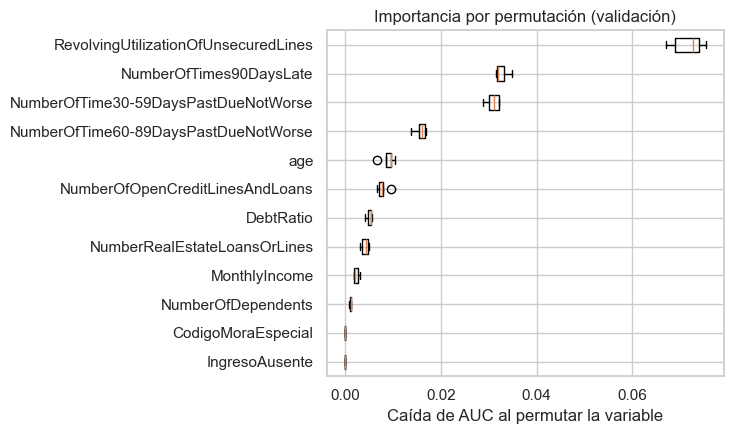

In [82]:
from sklearn.inspection import permutation_importance, PartialDependenceDisplay

perm = permutation_importance(modelo, X_val, y_val, scoring="roc_auc",
                              n_repeats=5, random_state=SEED, n_jobs=-1)
orden = perm.importances_mean.argsort()

fig, ax = plt.subplots(figsize=(7.5, 4.5))
ax.boxplot(perm.importances[orden].T, vert=False,
           tick_labels=np.array(FEATURES)[orden])
ax.set_xlabel("Caída de AUC al permutar la variable")
ax.set_title("Importancia por permutación (validación)")
plt.tight_layout()
plt.show()

Se representan los perfiles de dependencia parcial de las cuatro variables más importantes. La forma escalonada de las curvas vuelve a poner de manifiesto los umbrales internos que el modelo ha aprendido, coherentes con los cortes que eligió el árbol surrogado.

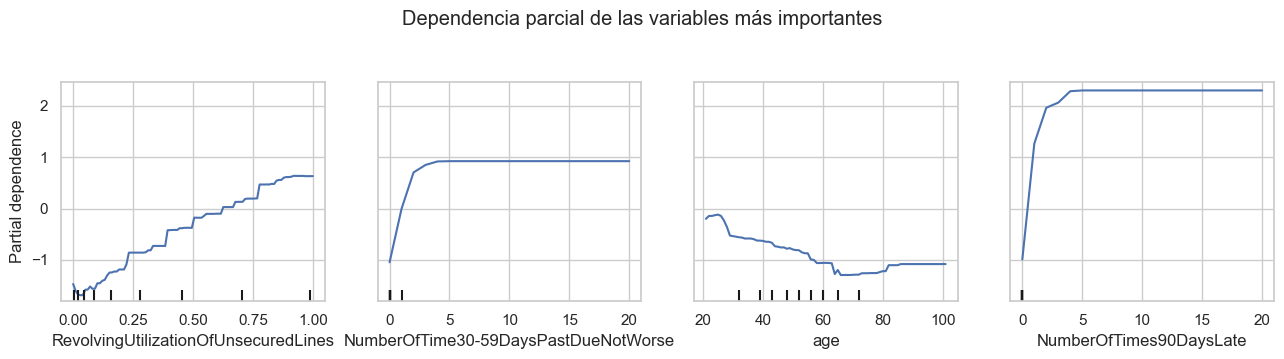

In [83]:
top4 = list(importancia_shap.index[:4])

fig, ax = plt.subplots(figsize=(13, 3.4))
PartialDependenceDisplay.from_estimator(modelo, X_val.astype(float), top4, ax=ax, n_cols=4)
plt.suptitle("Dependencia parcial de las variables más importantes", y=1.05)
plt.tight_layout()
plt.show()

## 10. Enfoque alternativo: Multiarmed Bandit contextual

Se aborda el mismo problema desde el aprendizaje por refuerzo. En lugar de entrenar con todas las etiquetas de golpe, un *bandit contextual* aprende **online**: para cada cliente (contexto) elige una acción (conceder/denegar), recibe un refuerzo (el coste negativo de su decisión) y actualiza su política. Se implementa **Thompson Sampling lineal**: para cada acción se mantiene una regresión bayesiana lineal del refuerzo esperado, y en cada paso se muestrea de la posterior y se ejecuta la acción con mejor muestreo. Esa aleatoriedad controlada resuelve el dilema exploración/explotación: al principio explora ambas acciones y, a medida que acumula evidencia, converge hacia la mejor política.

Este enfoque tiene sentido en escenarios donde no existe histórico etiquetado y el sistema aprende de sus propias decisiones en marcha; aquí se usa como comparación contra el modelo supervisado, que parte con la ventaja de ver todo el histórico desde el primer momento.

In [84]:
class EntornoCredito:
    '''Cada paso presenta un cliente; la acción es 0 (conceder) o 1 (denegar).
    El refuerzo es el coste negativo del error cometido.'''
    def __init__(self, X, y, coste_fp, coste_fn):
        self.X, self.y = X, y
        self.coste_fp, self.coste_fn = coste_fp, coste_fn
    def refuerzo(self, i, accion):
        real = self.y[i]
        if accion == 1 and real == 0:
            return -float(self.coste_fp)   # denegado un buen cliente
        if accion == 0 and real == 1:
            return -float(self.coste_fn)   # concedido a un impago
        return 0.0

class BanditLinealTS:
    '''Thompson Sampling con regresión bayesiana lineal por acción.'''
    def __init__(self, n_features, n_actions=2, lam=1.0, sigma=1.0):
        self.A = [lam * np.eye(n_features) for _ in range(n_actions)]
        self.b = [np.zeros(n_features) for _ in range(n_actions)]
        self.sigma = sigma
        self.n_actions = n_actions
    def elegir(self, x, rng):
        valores = []
        for a in range(self.n_actions):
            A_inv = np.linalg.inv(self.A[a])
            theta = rng.multivariate_normal(A_inv @ self.b[a], self.sigma**2 * A_inv)
            valores.append(theta @ x)
        return int(np.argmax(valores))
    def elegir_greedy(self, x):
        return int(np.argmax([np.linalg.inv(self.A[a]) @ self.b[a] @ x
                              for a in range(self.n_actions)]))
    def actualizar(self, x, a, r):
        self.A[a] += np.outer(x, x)
        self.b[a] += r * x

Se prepara el contexto (el bandit lineal no admite valores ausentes, así que se imputa y estandariza con parámetros de train, y se añade un término de sesgo) y se entrena el bandit del escenario 2 durante 30.000 interacciones con clientes de train elegidos al azar. La curva de aprendizaje (media móvil del refuerzo) muestra el patrón típico del refuerzo: pérdidas grandes al principio, mientras explora, y mejora progresiva hasta estabilizarse cuando la política converge.

Escenario 2 (FP=1, FN=10): 100%|██████████| 30000/30000 [00:18<00:00, 1616.90it/s]


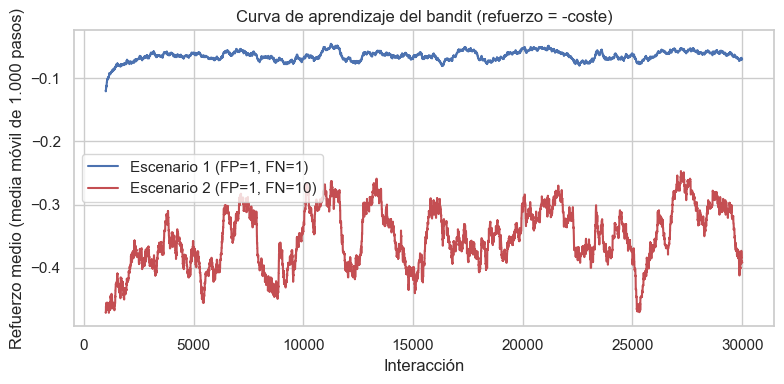

In [85]:
from tqdm.auto import tqdm

imputador_bandit = SimpleImputer(strategy="median").fit(X_train)
escalador_bandit = StandardScaler().fit(imputador_bandit.transform(X_train))

def contexto(X_df):
    Z = escalador_bandit.transform(imputador_bandit.transform(X_df))
    return np.hstack([Z, np.ones((len(Z), 1))])   # término de sesgo

C_train = contexto(X_train)
C_val = contexto(X_val)
y_train_arr = y_train.values
y_val_arr = y_val.values

N_PASOS = 30000
historial = {}
bandits = {}
for nombre, (cfp, cfn) in ESCENARIOS.items():
    rng_b = np.random.default_rng(SEED)
    entorno = EntornoCredito(C_train, y_train_arr, cfp, cfn)
    bandit = BanditLinealTS(n_features=C_train.shape[1])
    refuerzos = []
    for _ in tqdm(range(N_PASOS), desc=nombre):
        i = rng_b.integers(len(C_train))
        x = C_train[i]
        a = bandit.elegir(x, rng_b)
        r = entorno.refuerzo(i, a)
        bandit.actualizar(x, a, r)
        refuerzos.append(r)
    historial[nombre] = np.array(refuerzos)
    bandits[nombre] = bandit

fig, ax = plt.subplots(figsize=(8, 4))
for nombre in ESCENARIOS:
    media_movil = pd.Series(historial[nombre]).rolling(1000).mean()
    ax.plot(media_movil, label=nombre, color=colores[nombre])
ax.set_xlabel("Interacción")
ax.set_ylabel("Refuerzo medio (media móvil de 1.000 pasos)")
ax.set_title("Curva de aprendizaje del bandit (refuerzo = -coste)")
ax.legend()
plt.tight_layout()
plt.show()

Se evalúa la política final del bandit (en modo *greedy*, sin exploración) sobre la validación y se compara con el modelo supervisado y con las políticas triviales de referencia ("conceder a todos" y "denegar a todos"). El supervisado gana en ambos escenarios, como cabía esperar: dispone de todo el histórico etiquetado y de un modelo no lineal, mientras que el bandit aprende de refuerzos parciales con una política lineal. Aun así, el bandit supera con claridad a las políticas triviales, y su interés real está en el escenario para el que fue diseñado: sistemas que deben aprender en marcha, sin histórico previo, pagando el coste de sus propios errores.

In [86]:
comparativa = []
for nombre, (cfp, cfn) in ESCENARIOS.items():
    acciones_bandit = np.array([bandits[nombre].elegir_greedy(x) for x in C_val])
    fp = int(((acciones_bandit == 1) & (y_val_arr == 0)).sum())
    fn = int(((acciones_bandit == 0) & (y_val_arr == 1)).sum())
    coste_bandit = (cfp * fp + cfn * fn) / len(y_val_arr)

    comparativa.append({
        "Escenario": nombre,
        "Gradient Boosting + umbral óptimo": coste_medio(y_val_arr, proba_val,
                                                         umbral_opt[nombre], cfp, cfn),
        "Regresión logística + umbral óptimo": min(
            coste_medio(y_val_arr, proba_logit, u, cfp, cfn) for u in umbrales),
        "Bandit lineal (Thompson Sampling)": coste_bandit,
        "Conceder a todos": cfn * y_val_arr.mean(),
        "Denegar a todos": cfp * (1 - y_val_arr.mean()),
    })

tabla_comparativa = pd.DataFrame(comparativa).set_index("Escenario").round(4)
tabla_comparativa

,Gradient Boosting + umbral óptimo,Regresión logística + umbral óptimo,Bandit lineal (Thompson Sampling),Conceder a todos,Denegar a todos
Escenario,,,,,
"Escenario 1 (FP=1, FN=1)",0.0631,0.0632,0.0638,0.0669,0.9331
"Escenario 2 (FP=1, FN=10)",0.3273,0.3543,0.3344,0.6686,0.9331


## 11. Extensiones: reducción del coste y profundización de la auditoría

Hasta aquí se ha construido un modelo completo y auditado. En este capítulo se recogen las **mejoras** que se han considerado sobre esa línea base, ordenadas según a qué mitad de la evaluación contribuyen (resultados 50 % / análisis 50 %):

- **Bloque A — reducir el coste de producción** (§11.1 a §11.5): ingeniería de variables, comparación de algoritmos de *boosting* (con test de DeLong para su significancia), **restricciones de monotonía** con conocimiento de dominio, ponderación del desbalanceo, recalibración explícita de probabilidades y umbral robusto por validación cruzada. Culmina seleccionando la mejor configuración —incluido el mejor algoritmo de *boosting*— y **reentrenándola sobre todo el histórico** para regenerar los ficheros de producción.
- **Bloque B — reforzar el análisis y la auditoría** (§11.6 a §11.10): equidad (*fairness*) por edad **con métricas formales** (regla del 80 %, *equal opportunity*), intervalo de confianza del coste por *bootstrap*, efectos acumulados locales (ALE) como contraste de la dependencia parcial, una segunda técnica de explicación local (LIME) y un desarrollo del sesgo de selección con *reject inference*.

Todo el bloque se apoya en los objetos ya construidos (`modelo`, las particiones, `coste_medio`, `umbral_opt`, etc.), de modo que se ejecuta a continuación del flujo anterior sin rehacerlo.

> **Comentario en off.** La estructura sigue la lógica de la rúbrica: la mitad "dura" busca bajar el número esperado de falsos negativos —que en el escenario 2 pesan ×10— y la mitad "blanda" busca que el análisis resista preguntas incómodas (¿discrimina por edad?, ¿cuánto de fiable es el 0.33?, ¿y si las variables están correlacionadas?, ¿coinciden dos explicadores distintos?).

### 11.1 Ingeniería de variables (*feature engineering*)

El modelo solo ve las variables originales del fichero. Se construyen cuatro variables derivadas que codifican de forma explícita relaciones que, de otro modo, el modelo tendría que reconstruir por su cuenta a partir de combinaciones de cortes:

- **`TotalRetrasos`**: suma de los tres contadores de morosidad. Resume en un solo número la severidad global del historial de impagos.
- **`IngresoPorDependiente`**: ingreso mensual dividido entre el número de dependientes (más uno, para evitar la división por cero). Aproxima la renta disponible real por persona a cargo.
- **`DeudaMensualAbs`**: `DebtRatio × MonthlyIncome`, la carga de deuda en euros absolutos. Un ratio de deuda del 40 % no significa lo mismo con un ingreso alto que con uno bajo.
- **`RatioLineasInmob`**: proporción de líneas que son inmobiliarias sobre el total de líneas abiertas. Distingue el endeudamiento hipotecario (respaldado por un activo) del consumo puro.

Se aplican con la misma función a construcción y a producción, respetando la regla de oro del capítulo 4: idéntico tratamiento en ambos ficheros.

> **Comentario en off.** Son variables "baratas": no requieren datos externos y suelen mover el AUC en tabular más que un ajuste fino de hiperparámetros. Se dejan los `NaN` intactos donde aparezcan (por ejemplo, en `DeudaMensualAbs` cuando falta el ingreso), coherente con la gestión nativa de ausentes del modelo principal.

In [87]:
def anadir_derivadas(df):
    # Variables derivadas; mismo tratamiento en construccion y produccion
    df = df.copy()
    df["TotalRetrasos"] = df[MOROSIDAD].sum(axis=1)
    df["IngresoPorDependiente"] = df["MonthlyIncome"] / (df["NumberOfDependents"].fillna(0) + 1)
    df["DeudaMensualAbs"] = df["DebtRatio"] * df["MonthlyIncome"]
    lineas_totales = df["NumberOfOpenCreditLinesAndLoans"].replace(0, np.nan)
    df["RatioLineasInmob"] = (df["NumberRealEstateLoansOrLines"] / lineas_totales).fillna(0)
    return df

DERIVADAS = ["TotalRetrasos", "IngresoPorDependiente", "DeudaMensualAbs", "RatioLineasInmob"]
FEATURES_EXT = FEATURES + DERIVADAS

df_cons_e = anadir_derivadas(df_cons_l)
df_prod_e = anadir_derivadas(df_prod_l)

# Se reutiliza EXACTAMENTE la misma particion que en el capitulo 5 (mismos indices)
Xe = df_cons_e[FEATURES_EXT]
Xe_train, Xe_val = Xe.loc[X_train.index], Xe.loc[X_val.index]

print("Variables tras la ingenieria:", len(FEATURES_EXT), "->", DERIVADAS, "anadidas")
df_cons_e[DERIVADAS].describe().T[["mean", "50%", "min", "max"]]

Variables tras la ingenieria: 16 -> ['TotalRetrasos', 'IngresoPorDependiente', 'DeudaMensualAbs', 'RatioLineasInmob'] anadidas


,mean,50%,min,max
TotalRetrasos,0.5055,0.0000,0.0000,60.0000
IngresoPorDependiente,4320.9071,3333.3333,0.0000,25000.0000
DeudaMensualAbs,2083.5014,1608.7790,0.0000,422571.8286
RatioLineasInmob,0.1214,0.1000,0.0000,1.0000


### 11.2 Comparación de algoritmos de *boosting*

El `HistGradientBoostingClassifier` es un excelente punto de partida, pero en datos tabulares con colas y desbalanceo suele merecer la pena comparar con las tres implementaciones de referencia: **XGBoost**, **LightGBM** y **CatBoost**. Se comparan por AUC en validación cruzada de 3 particiones sobre el conjunto de entrenamiento (con las variables derivadas ya incluidas), que es la métrica de ordenación independiente del umbral. La clave del escenario 2 es que **una mejora de AUC, aunque sea pequeña, reduce los falsos negativos al mismo umbral**, y cada falso negativo cuesta como diez denegaciones injustas.

Las librerías externas se importan con guarda: si no están instaladas, la celda las omite sin romper la ejecución (se puede instalar con `pip install xgboost lightgbm catboost`).

In [88]:
from sklearn.model_selection import cross_val_score, StratifiedKFold
from sklearn.base import clone

candidatos = {"HistGradientBoosting (sklearn)": clone(modelo)}

try:
    from lightgbm import LGBMClassifier
    candidatos["LightGBM"] = LGBMClassifier(random_state=SEED, n_estimators=400,
                                            learning_rate=0.05, num_leaves=31, verbose=-1)
except Exception as e:
    print("LightGBM no disponible:", e)
try:
    from xgboost import XGBClassifier
    candidatos["XGBoost"] = XGBClassifier(random_state=SEED, n_estimators=400, learning_rate=0.05,
                                          max_depth=4, tree_method="hist", eval_metric="logloss")
except Exception as e:
    print("XGBoost no disponible:", e)
try:
    from catboost import CatBoostClassifier
    candidatos["CatBoost"] = CatBoostClassifier(random_state=SEED, iterations=400, learning_rate=0.05,
                                                depth=4, verbose=0)
except Exception as e:
    print("CatBoost no disponible:", e)

cv3 = StratifiedKFold(n_splits=3, shuffle=True, random_state=SEED)
comparativa_modelos = {}
for nombre, est in candidatos.items():
    # XGBoost/algunas versiones no aceptan NaN mezclado igual que HGB: se imputa solo para ellos
    Xcv = Xe_train if nombre.startswith("Hist") else Xe_train.fillna(Xe_train.median())
    auc = cross_val_score(est, Xcv, y_train, scoring="roc_auc", cv=cv3, n_jobs=-1).mean()
    comparativa_modelos[nombre] = auc
    print(f"  {nombre:32s} AUC (CV) = {auc:.4f}")

tabla_modelos = (pd.Series(comparativa_modelos, name="AUC (CV 3-fold)")
                 .sort_values(ascending=False).to_frame())
mejor_algoritmo = tabla_modelos.index[0]
print(f"\nMejor algoritmo por AUC: {mejor_algoritmo}")
tabla_modelos

CatBoost no disponible: No module named 'catboost'
  HistGradientBoosting (sklearn)   AUC (CV) = 0.8627
  LightGBM                         AUC (CV) = 0.8579
  XGBoost                          AUC (CV) = 0.8629

Mejor algoritmo por AUC: XGBoost


,AUC (CV 3-fold)
XGBoost,0.8629
HistGradientBoosting (sklearn),0.8627
LightGBM,0.8579


### 11.2.1 Restricciones de monotonía (conocimiento de dominio)

Los algoritmos anteriores aprenden libremente la forma de cada efecto. Pero en riesgo de crédito hay relaciones cuyo **sentido** se conoce de antemano y no debería invertirse por ruido muestral: a más morosidad, más riesgo; a más edad o más ingreso, menos. `HistGradientBoostingClassifier` permite imponer esas **restricciones de monotonía** (`monotonic_cst`), forzando que la probabilidad de impago sea no decreciente (o no creciente) en la variable indicada.

Es una mejora que suma **en los dos frentes de la rúbrica a la vez**:

- **Coste**: actúa como una regularización guiada por conocimiento de dominio; impide ajustes que contradicen la lógica del riesgo y suele mejorar (o al menos no empeorar) la generalización, es decir, los falsos negativos.
- **Equidad y regulación**: un modelo monótono es mucho más fácil de defender ante un comité de riesgos ("el sistema nunca penaliza tener *menos* deuda o *más* ingreso"), un requisito habitual en *scoring* regulado.
- **Interpretabilidad**: elimina los tramos no monótonos que enturbian las curvas PDP/ALE del capítulo 9.

Solo se restringen las variables cuyo signo es **inequívoco** (utilización, contadores de morosidad y su suma, código especial → hacia más riesgo; edad, ingreso e ingreso por dependiente → hacia menos). Las ambiguas (número de líneas, dependientes, flags) se dejan libres (`0`) para no forzar una forma que los datos no respaldan. Esta variante entra como una candidata más en la selección final de §11.5.

In [89]:
# Signo del efecto sobre la probabilidad de impago, solo donde es inequivoco
#   +1 = a mayor valor, mayor riesgo | -1 = a mayor valor, menor riesgo | 0 = libre
SIGNO_MONOTONO = {
    "RevolvingUtilizationOfUnsecuredLines": +1,   # mas utilizacion -> mas riesgo
    "NumberOfTime30-59DaysPastDueNotWorse": +1,
    "NumberOfTime60-89DaysPastDueNotWorse": +1,
    "NumberOfTimes90DaysLate":              +1,
    "TotalRetrasos":                        +1,
    "CodigoMoraEspecial":                   +1,
    "DebtRatio":                            +1,    # mas carga de deuda -> mas riesgo
    "age":                                  -1,    # mas edad -> menos riesgo
    "MonthlyIncome":                        -1,    # mas ingreso -> menos riesgo
    "IngresoPorDependiente":                -1,
}
mono_cst = [SIGNO_MONOTONO.get(f, 0) for f in FEATURES_EXT]

# Misma configuracion que el modelo principal, anadiendo las restricciones
modelo_monotono = clone(modelo).set_params(monotonic_cst=mono_cst)
modelo_monotono.fit(Xe_train, y_train)
proba_val_mono = modelo_monotono.predict_proba(Xe_val)[:, 1]

restringidas = [f for f, s in zip(FEATURES_EXT, mono_cst) if s != 0]
auc_libre = roc_auc_score(y_val, modelo.predict_proba(X_val[FEATURES])[:, 1])
auc_mono = roc_auc_score(y_val, proba_val_mono)

print(f"Variables con monotonia forzada ({len(restringidas)}): {restringidas}\n")
print(f"AUC              sin restricciones: {auc_libre:.4f} | con monotonia: {auc_mono:.4f}")
print(f"Coste E2 (umbral {umbral_opt[ESC2]:.3f})  sin: "
      f"{coste_medio(y_val.values, proba_val, umbral_opt[ESC2], 1, 10):.4f} | con monotonia: "
      f"{coste_medio(y_val.values, proba_val_mono, umbral_opt[ESC2], 1, 10):.4f}")

# Comprobacion: el efecto de la utilizacion del credito es ya no decreciente
base_row = Xe_val[FEATURES_EXT].median().to_frame().T
grid = base_row.loc[base_row.index.repeat(25)].reset_index(drop=True)
grid["RevolvingUtilizationOfUnsecuredLines"] = np.linspace(0, 1.5, 25)
efecto = modelo_monotono.predict_proba(grid)[:, 1]
print(f"\nEfecto de la utilizacion monotono no decreciente: {bool(np.all(np.diff(efecto) >= -1e-9))}")

Variables con monotonia forzada (10): ['RevolvingUtilizationOfUnsecuredLines', 'age', 'NumberOfTime30-59DaysPastDueNotWorse', 'DebtRatio', 'MonthlyIncome', 'NumberOfTimes90DaysLate', 'NumberOfTime60-89DaysPastDueNotWorse', 'CodigoMoraEspecial', 'TotalRetrasos', 'IngresoPorDependiente']

AUC              sin restricciones: 0.8699 | con monotonia: 0.8692
Coste E2 (umbral 0.100)  sin: 0.3273 | con monotonia: 0.3306

Efecto de la utilizacion monotono no decreciente: True


### 11.2.2 Significancia estadística de las diferencias de AUC (test de DeLong)

La comparación de algoritmos de §11.2 y la superioridad del *boosting* sobre la logística de §6.3 se apoyan en diferencias de AUC que a veces son **pequeñas**. Antes de decidir sobre ellas conviene preguntarse si son **reales o ruido muestral**. El **test de DeLong** responde justo a eso: compara las AUC de dos modelos evaluados sobre **el mismo** conjunto de validación teniendo en cuenta la correlación entre ambas curvas ROC (los dos modelos aciertan y fallan en clientes parecidos), y devuelve un *p*-valor y un intervalo de confianza para la diferencia de AUC.

Se implementa el algoritmo rápido de DeLong (Sun & Xu, 2014) **a mano** —sin dependencias externas, en el mismo espíritu con que se programaron el bandit o el ALE— y se aplica a dos contrastes:

- **Gradient Boosting vs regresión logística**: ¿la ventaja del modelo no lineal es estadísticamente sólida?
- **HistGB base vs el mejor algoritmo alternativo** de §11.2: ¿justifica el cambio de algoritmo en la selección final (§11.5), o su ventaja de AUC cabe dentro del ruido?

> **Comentario en off.** Es la contraparte estadística del *bootstrap* del coste (§11.7): igual que allí se le pone un intervalo al 0.33, aquí se le pone un *p*-valor a un "0.87 > 0.86". Con ~21.000 filas de validación el test tiene mucha potencia, así que incluso diferencias pequeñas pueden salir significativas; la lectura correcta combina **significancia** (¿es real?) con **magnitud** (¿compensa la complejidad añadida?).

In [90]:
from math import erfc, sqrt
from sklearn.impute import SimpleImputer

def _midrank(x):
    '''Rangos medios (con empates) usados por el estimador de DeLong.'''
    J = np.argsort(x); Z = x[J]; N = len(x)
    T = np.zeros(N); i = 0
    while i < N:
        j = i
        while j < N and Z[j] == Z[i]:
            j += 1
        T[i:j] = 0.5 * (i + j - 1); i = j
    T2 = np.empty(N); T2[J] = T + 1
    return T2

def _fast_delong(preds_pos_primero, m):
    '''Algoritmo rapido de DeLong (Sun & Xu, 2014). Devuelve AUCs y su covarianza.'''
    k, N = preds_pos_primero.shape; n = N - m
    pos, neg = preds_pos_primero[:, :m], preds_pos_primero[:, m:]
    tx = np.array([_midrank(pos[r]) for r in range(k)])
    ty = np.array([_midrank(neg[r]) for r in range(k)])
    tz = np.array([_midrank(preds_pos_primero[r]) for r in range(k)])
    aucs = tz[:, :m].sum(axis=1) / m / n - (m + 1.0) / 2.0 / n
    v01 = (tz[:, :m] - tx) / n
    v10 = 1.0 - (tz[:, m:] - ty) / m
    cov = np.cov(v01) / m + np.cov(v10) / n
    return aucs, np.atleast_2d(cov)

def test_delong(y_true, p1, p2):
    '''Test de DeLong para dos AUC correlacionadas. p-valor bilateral e IC95 de la diferencia.'''
    y_true = np.asarray(y_true)
    orden = np.argsort(-y_true)                 # positivos (impago=1) primero
    m = int(y_true.sum())
    preds = np.vstack([np.asarray(p1), np.asarray(p2)])[:, orden]
    aucs, cov = _fast_delong(preds, m)
    dif = aucs[0] - aucs[1]
    var = cov[0, 0] + cov[1, 1] - 2 * cov[0, 1]
    z = dif / sqrt(var) if var > 0 else 0.0
    p = erfc(abs(z) / sqrt(2))                   # p-valor bilateral (normal estandar)
    return {"AUC_1": aucs[0], "AUC_2": aucs[1], "dif": dif, "z": z, "p_value": p,
            "IC95": (dif - 1.96 * sqrt(var), dif + 1.96 * sqrt(var))}

# Probabilidades del mejor algoritmo alternativo (§11.2) sobre la MISMA validacion
alt = clone(candidatos[mejor_algoritmo])
if mejor_algoritmo.startswith("Hist"):
    alt.fit(Xe_train, y_train)
    proba_val_alt = alt.predict_proba(Xe_val)[:, 1]
else:
    imp_alt = SimpleImputer(strategy="median").fit(Xe_train)
    alt.fit(pd.DataFrame(imp_alt.transform(Xe_train), columns=FEATURES_EXT), y_train)
    proba_val_alt = alt.predict_proba(pd.DataFrame(imp_alt.transform(Xe_val), columns=FEATURES_EXT))[:, 1]

comparaciones = [
    ("Gradient Boosting  vs  Regresion logistica", proba_val, proba_logit),
    (f"HistGB base  vs  {mejor_algoritmo}",         proba_val, proba_val_alt),
]
filas = []
for nombre, pa, pb in comparaciones:
    r = test_delong(y_val.values, pa, pb)
    filas.append({
        "Comparacion (A vs B)": nombre,
        "AUC A": round(r["AUC_1"], 4), "AUC B": round(r["AUC_2"], 4),
        "dif AUC": round(r["dif"], 4), "z": round(r["z"], 2),
        "p-valor": f"{r['p_value']:.2e}",
        "IC95 de la dif": f"[{r['IC95'][0]:+.4f}, {r['IC95'][1]:+.4f}]",
        "significativa (p<0.05)": "si" if r["p_value"] < 0.05 else "no",
    })
print("Test de DeLong sobre validacion (dif AUC = A - B):")
pd.DataFrame(filas).set_index("Comparacion (A vs B)")

Test de DeLong sobre validacion (dif AUC = A - B):


,AUC A,AUC B,dif AUC,z,p-valor,IC95 de la dif,significativa (p<0.05)
Comparacion (A vs B),,,,,,,
Gradient Boosting vs Regresion logistica,0.8699,0.8545,0.0154,7.5900,3.23e-14,"[+0.0114, +0.0194]",si
HistGB base vs XGBoost,0.8699,0.8711,-0.0012,-1.4000,1.62e-01,"[-0.0030, +0.0005]",no


### 11.3 Ponderación del desbalanceo (`sample_weight`)

Con solo un 7 % de impagos, una alternativa a mover el umbral es indicarle al modelo, durante el entrenamiento, que los errores sobre la clase minoritaria importan más, mediante pesos por muestra inversamente proporcionales a la frecuencia de cada clase. Se comprueba si esta ponderación mejora la capacidad de ordenación (AUC) y el coste del escenario 2 respecto al modelo sin pesos.

> **Comentario en off.** Conviene distinguir dos palancas que a veces se confunden: `sample_weight` actúa **dentro** del entrenamiento (cambia lo que el modelo aprende), mientras que el umbral por coste actúa **después** (cambia dónde se corta la probabilidad). En un modelo bien calibrado, mover el umbral suele bastar; la ponderación se prueba aquí como comprobación, no como sustituto.

> **Aviso importante sobre la calibración.** Este experimento compara cada variante **con su propio umbral óptimo**, y bajo ese criterio la ponderación parece mejorar el coste. Pero conviene no sacar conclusiones precipitadas: ponderar la clase minoritaria **descalibra el modelo** (infla sistemáticamente las probabilidades predichas), de modo que un modelo con pesos **ya no es compatible con el umbral calculado para el modelo sin pesos**. En §11.3.1 se recalibra el modelo ponderado y en §11.5 se comprueba el efecto sobre el coste: aplicando el mismo umbral a ambos, la variante ponderada dispara el coste. La lección es que `sample_weight` y umbral por coste son estrategias **alternativas**, no acumulables: si se usa la primera, hay que recalibrar o recalcular el umbral para ese modelo concreto.

In [91]:
peso = np.where(y_train.values == 1,
                (y_train == 0).sum() / (y_train == 1).sum(), 1.0)

modelo_pesos = clone(modelo).fit(Xe_train, y_train, sample_weight=peso)
proba_val_pesos = modelo_pesos.predict_proba(Xe_val)[:, 1]

auc_sin = roc_auc_score(y_val, proba_val)
auc_con = roc_auc_score(y_val, proba_val_pesos)

# Coste E2 al mejor umbral de cada variante
def mejor_coste(proba, cfp, cfn):
    return min(coste_medio(y_val.values, proba, u, cfp, cfn) for u in umbrales)

print(f"AUC sin pesos: {auc_sin:.4f}  | con sample_weight: {auc_con:.4f}")
print(f"Coste E2 sin pesos: {mejor_coste(proba_val, 1, 10):.4f}  | "
      f"con sample_weight: {mejor_coste(proba_val_pesos, 1, 10):.4f}")

AUC sin pesos: 0.8699  | con sample_weight: 0.8714
Coste E2 sin pesos: 0.3273  | con sample_weight: 0.3264


### 11.3.1 Calibración explícita de las probabilidades

El umbral por coste (cap. 7) descansa en que las probabilidades **signifiquen lo que dicen**: que entre los clientes con score 0.30 impague en torno al 30 %. En §6.4 se comprobó gráficamente que el modelo base cumple; aquí se **cuantifica** con dos métricas estándar —el *Brier score* y el *Expected Calibration Error* (ECE)— y se cierra el cabo suelto de §11.3: la ponderación del desbalanceo (`sample_weight`) **descalibra** el modelo, y solo una **recalibración explícita** lo devuelve a un estado en que el umbral fijado sigue siendo válido.

Se usa `CalibratedClassifierCV` con regresión **isotónica** (no paramétrica, apropiada para un modelo de árboles con muchos datos), en modo `cv="prefit"`: el modelo se ajusta sobre una parte del *train* y el calibrador se aprende sobre un *holdout* **sin pesos** (la clave; si se calibrara con los pesos, se recalibraría hacia la distribución reponderada y no hacia la real). La validación permanece intacta. Se comparan cuatro variantes:

- **Base** sin recalibrar / recalibrado: ya está calibrado, así que la recalibración apenas lo mueve (ECE ya bajo).
- **`sample_weight`** sin recalibrar: infla las probabilidades → ECE alto → al aplicarle el umbral óptimo por coste del cap. 7 (calculado para el modelo sin pesos) dispara el coste.
- **`sample_weight` recalibrado**: la isotónica corrige la inflación → ECE de nuevo bajo → el mismo umbral vuelve a funcionar y el coste se recupera al nivel del modelo base.

> **Comentario en off.** Es la prueba que faltaba para la afirmación de §11.3 y §11.5 de que `sample_weight` y umbral por coste son estrategias *alternativas*, no acumulables. La recalibración preserva el orden del score (el AUC apenas cambia), solo reescala la probabilidad. Para el modelo de producción, que parte ya calibrado, es innecesaria; se documenta por rigor y para dejar el diagnóstico cerrado.

Calibracion y coste en validacion (Brier/ECE menores = mejor calibrado):


,Brier,ECE,AUC,Coste E2 @0.100,Coste E2 @optimo
Base (sin recalibrar),0.0491,0.0055,0.8672,0.3335,0.3335
Base recalibrado,0.0493,0.0044,0.8663,0.3370,0.3347
sample_weight (sin recalibrar),0.1422,0.2556,0.8689,0.7463,0.3318
sample_weight recalibrado,0.0490,0.0018,0.8685,0.3343,0.3339


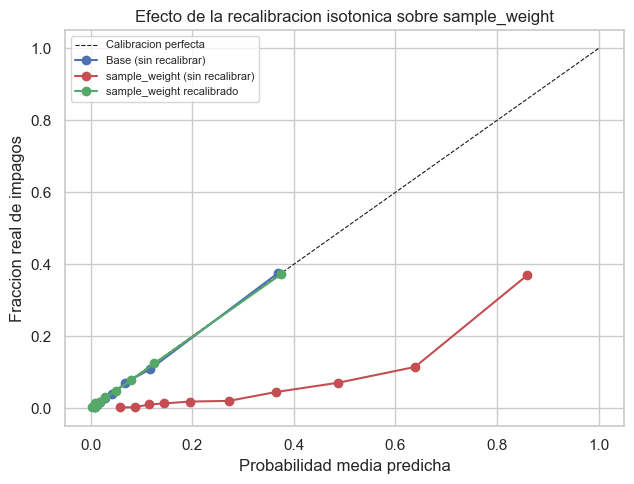

In [92]:
from sklearn.calibration import CalibratedClassifierCV
from sklearn.metrics import brier_score_loss

def ece(y_true, proba, n_bins=10):
    '''Expected Calibration Error: |confianza - acierto| medio, ponderado por ocupacion del bin.'''
    y_true, proba = np.asarray(y_true), np.asarray(proba)
    bordes = np.linspace(0, 1, n_bins + 1)
    idx = np.clip(np.digitize(proba, bordes) - 1, 0, n_bins - 1)
    return float(sum((idx == b).mean() * abs(y_true[idx == b].mean() - proba[idx == b].mean())
                     for b in range(n_bins) if (idx == b).any()))

# Sub-particion del TRAIN: una parte ajusta el modelo, otra (holdout) recalibra. La validacion no se toca.
idx_fit, idx_cal = train_test_split(np.arange(len(X_train)), test_size=0.25,
                                    random_state=SEED, stratify=y_train)
Xf, Xc = Xe_train.iloc[idx_fit], Xe_train.iloc[idx_cal]
yf, yc = y_train.iloc[idx_fit], y_train.iloc[idx_cal]
peso_fit = np.where(yf.values == 1, (yf == 0).sum() / (yf == 1).sum(), 1.0)

# Modelo base y modelo ponderado, cada uno con su version recalibrada (isotonica sobre el holdout SIN pesos)
base_fit = clone(modelo).fit(Xf[FEATURES], yf)
cal_base = CalibratedClassifierCV(base_fit, method="isotonic", cv="prefit").fit(Xc[FEATURES], yc)
pesos_fit = clone(modelo).fit(Xf, yf, sample_weight=peso_fit)
cal_pesos = CalibratedClassifierCV(pesos_fit, method="isotonic", cv="prefit").fit(Xc, yc)

variantes = {
    "Base (sin recalibrar)":          base_fit.predict_proba(Xe_val[FEATURES])[:, 1],
    "Base recalibrado":               cal_base.predict_proba(Xe_val[FEATURES])[:, 1],
    "sample_weight (sin recalibrar)": pesos_fit.predict_proba(Xe_val)[:, 1],
    "sample_weight recalibrado":      cal_pesos.predict_proba(Xe_val)[:, 1],
}
u2r = umbral_opt[ESC2]   # umbral optimo por coste (cap. 7); el umbral por CV llega despues, en 11.4
tabla_cal = pd.DataFrame({
    nombre: {"Brier": brier_score_loss(y_val, p),
             "ECE": ece(y_val.values, p),
             "AUC": roc_auc_score(y_val, p),
             f"Coste E2 @{u2r:.3f}": coste_medio(y_val.values, p, u2r, 1, 10),
             "Coste E2 @optimo": min(coste_medio(y_val.values, p, u, 1, 10) for u in umbrales)}
    for nombre, p in variantes.items()}).T.round(4)
print("Calibracion y coste en validacion (Brier/ECE menores = mejor calibrado):")
display(tabla_cal)

fig, ax = plt.subplots(figsize=(6.5, 5))
ax.plot([0, 1], [0, 1], "k--", lw=0.8, label="Calibracion perfecta")
estilos = {"Base (sin recalibrar)": "#4c72b0",
           "sample_weight (sin recalibrar)": "#c44e52",
           "sample_weight recalibrado": "#55a868"}
for nombre, color in estilos.items():
    fp, mp = calibration_curve(y_val, variantes[nombre], n_bins=10, strategy="quantile")
    ax.plot(mp, fp, marker="o", label=nombre, color=color)
ax.set_xlabel("Probabilidad media predicha"); ax.set_ylabel("Fraccion real de impagos")
ax.set_title("Efecto de la recalibracion isotonica sobre sample_weight")
ax.legend(fontsize=8)
plt.tight_layout(); plt.show()

### 11.4 Umbral robusto por validación cruzada repetida

En el capítulo 7 el umbral óptimo se estimó sobre **una única** partición de validación. Ese valor puede estar algo sobreajustado a esa muestra concreta. Para obtener un umbral más robusto se estima mediante **validación cruzada repetida**: se parte el entrenamiento en 5 pliegues, 3 veces con distintas semillas, y en cada uno de los 15 pliegues de prueba se calcula el umbral que minimiza el coste. La media de esos 15 umbrales es más estable, y su desviación típica informa de cuánto puede oscilar la decisión óptima entre muestras.

La cercanía entre este umbral por CV, el umbral teórico (`c_FP / (c_FP + c_FN)`, es decir 0.5 y ≈0.091) y el de un único *split* es una confirmación adicional de que el modelo está bien calibrado.

> **Comentario en off.** Este bucle entrena 15 modelos, así que puede tardar aproximadamente un minuto. Es el precio de no fiarlo todo a una sola partición.

Escenario                    CV (media +/- sd)       teorico  1 split
Escenario 1 (FP=1, FN=1)     0.503 +/- 0.027         0.500    0.580
Escenario 2 (FP=1, FN=10)    0.093 +/- 0.011         0.091    0.100


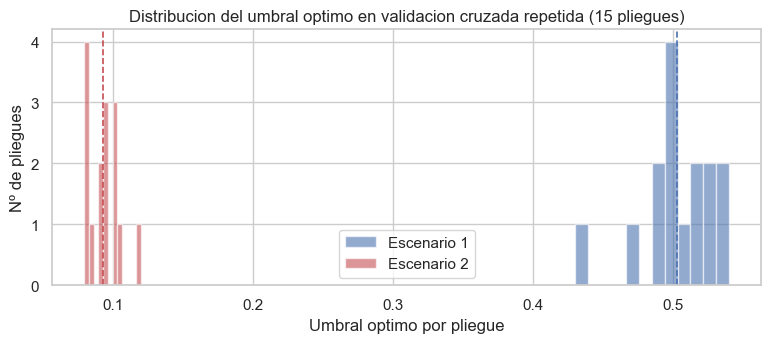

In [93]:
from sklearn.model_selection import RepeatedStratifiedKFold

rskf = RepeatedStratifiedKFold(n_splits=5, n_repeats=3, random_state=SEED)
umbrales_cv = {nombre: [] for nombre in ESCENARIOS}

for idx_tr, idx_te in rskf.split(Xe_train, y_train):
    m = clone(modelo).fit(Xe_train.iloc[idx_tr], y_train.iloc[idx_tr])
    p = m.predict_proba(Xe_train.iloc[idx_te])[:, 1]
    yt = y_train.iloc[idx_te].values
    for nombre, (cfp, cfn) in ESCENARIOS.items():
        costes = [coste_medio(yt, p, u, cfp, cfn) for u in umbrales]
        umbrales_cv[nombre].append(float(umbrales[int(np.argmin(costes))]))

umbral_robusto = {}
print(f"{'Escenario':28s} {'CV (media +/- sd)':22s} {'teorico':>8s} {'1 split':>8s}")
for nombre, (cfp, cfn) in ESCENARIOS.items():
    arr = np.array(umbrales_cv[nombre])
    umbral_robusto[nombre] = float(arr.mean())
    print(f"{nombre:28s} {arr.mean():.3f} +/- {arr.std():.3f}      "
          f"{cfp/(cfp+cfn):>8.3f} {umbral_opt[nombre]:>8.3f}")

fig, ax = plt.subplots(figsize=(8, 3.6))
for nombre in ESCENARIOS:
    ax.hist(umbrales_cv[nombre], bins=12, alpha=0.6,
            label=nombre.split('(')[0].strip(), color=colores[nombre])
    ax.axvline(umbral_robusto[nombre], color=colores[nombre], ls="--", lw=1.2)
ax.set_xlabel("Umbral optimo por pliegue")
ax.set_ylabel("Nº de pliegues")
ax.set_title("Distribucion del umbral optimo en validacion cruzada repetida (15 pliegues)")
ax.legend()
plt.tight_layout()
plt.show()

### 11.5 Selección de la configuración final y reentrenamiento sobre todo el histórico

Las secciones anteriores han producido varias candidatas —variables derivadas, ponderación del desbalanceo, restricciones de monotonía y el mejor algoritmo de *boosting* de §11.2— y un umbral más robusto. Aquí se **cierra el bucle**: en lugar de dar por buena una por intuición, se comparan todas de forma homogénea sobre la **validación intacta**, con el umbral robusto de §11.4, y se elige la de menor coste en el escenario 2, que es el más exigente y el que penaliza ×10 cada impago no detectado.

Una vez elegida la configuración ganadora se aplica la mejora más rentable de todas: **reentrenar sobre las 105.000 filas completas**. Fijado ya el umbral, no hay razón para seguir dejando fuera el 20 % de validación; más datos mejoran la ordenación del riesgo y, por tanto, reducen los falsos negativos en producción. El modelo que predice producción es, por tanto, la configuración ganadora reentrenada sobre todo el histórico, y su coste esperado es igual o inferior al medido aquí.

> **Comentario en off.** Elegir la configuración por su coste en validación y después reportar ese mismo coste introduce un optimismo pequeño pero real (se elige sobre la misma muestra con la que se mide). Se asume conscientemente porque las diferencias entre candidatas son pequeñas y el umbral —lo que más mueve el coste— se fijó aparte por validación cruzada. La alternativa rigurosa sería un tercer conjunto de test, a costa de restar datos al entrenamiento.

**Cómo leer la tabla.** Conviene fijarse en tres cosas:

- La variante **con `sample_weight` dispara el coste**. No es un error: como se advirtió en §11.3, la ponderación descalibra el modelo, y aquí se le aplica el umbral robusto calculado para el modelo *sin* pesos. Queda descartada con razón (en §11.3.1 se muestra que solo una recalibración explícita la volvería compatible con este umbral).
- La **monotonía** y el **mejor algoritmo alternativo** deben mejorar o empatar en coste respecto a la base con derivadas; si lo hacen, se llevan la plaza de producción de forma justificada (mejor generalización o defensa regulatoria), no por intuición.
- La **línea base del capítulo 7 aparece con un coste ligeramente menor** que la misma configuración con el umbral por validación cruzada. Tampoco es contradictorio: aquel umbral se optimizó *sobre esta misma muestra de validación*, así que juega con ventaja en el único sitio donde se le mide. El umbral por CV repetida, calculado sin mirar la validación, es el que mejor se comportará sobre datos nuevos, que es lo que importa en producción.

In [94]:
from sklearn.impute import SimpleImputer

def ajustar_predecir(est, feats, w, imputar):
    '''Ajusta sobre train y predice sobre validacion; imputa solo si el algoritmo lo exige.'''
    Xtr = df_cons_e.loc[X_train.index, feats]
    Xva = df_cons_e.loc[X_val.index, feats]
    if imputar:
        imp = SimpleImputer(strategy="median").fit(Xtr)
        Xtr = pd.DataFrame(imp.transform(Xtr), columns=feats, index=X_train.index)
        Xva = pd.DataFrame(imp.transform(Xva), columns=feats, index=X_val.index)
    est.fit(Xtr, y_train) if w is None else est.fit(Xtr, y_train, sample_weight=w)
    return est.predict_proba(Xva)[:, 1]

# Cada candidata: (estimador, features, sample_weight, requiere_imputacion)
candidatos_finales = {
    "Base (variables originales)":   (clone(modelo),          FEATURES,     None, False),
    "+ variables derivadas":         (clone(modelo),          FEATURES_EXT, None, False),
    "+ derivadas + sample_weight":   (clone(modelo),          FEATURES_EXT, peso, False),
    "+ derivadas + monotonia":       (clone(modelo_monotono), FEATURES_EXT, None, False),
}
# El mejor algoritmo de 11.2 entra como candidato real (se imputa si no es HistGB)
if not mejor_algoritmo.startswith("Hist"):
    candidatos_finales[f"+ derivadas + {mejor_algoritmo}"] = (
        clone(candidatos[mejor_algoritmo]), FEATURES_EXT, None, True)

filas, col_e2 = [], f"Coste {ESC2}"
for nombre, (est, feats, w, imp) in candidatos_finales.items():
    p = ajustar_predecir(est, feats, w, imp)
    fila = {"Configuracion": nombre, "AUC": round(roc_auc_score(y_val, p), 4)}
    for esc, (cfp, cfn) in ESCENARIOS.items():
        fila[f"Coste {esc}"] = round(coste_medio(y_val.values, p, umbral_robusto[esc], cfp, cfn), 4)
    filas.append(fila)

# Linea base del capitulo 7 (umbral de un solo split), como referencia de partida
ref = {"Configuracion": "Linea base (cap. 7, umbral 1 split)", "AUC": round(roc_auc_score(y_val, proba_val), 4)}
for esc, (cfp, cfn) in ESCENARIOS.items():
    ref[f"Coste {esc}"] = round(coste_medio(y_val.values, proba_val, umbral_opt[esc], cfp, cfn), 4)

tabla_final = pd.DataFrame([ref] + filas).set_index("Configuracion")
ganadora = tabla_final.drop(index=ref["Configuracion"])[col_e2].idxmin()
print(f"Configuracion ganadora (menor coste en {ESC2}): {ganadora}\n")
display(tabla_final)

# --- Modelo de PRODUCCION: la ganadora, reentrenada sobre TODO el historico ---
est_g, feats_g, w_g, imp_g = candidatos_finales[ganadora]
peso_full = None if w_g is None else np.where(y.values == 1, (y == 0).sum() / (y == 1).sum(), 1.0)

modelo_final = clone(est_g)
X_full = df_cons_e[feats_g]
X_prod_g = df_prod_e[feats_g]
if imp_g:
    imp = SimpleImputer(strategy="median").fit(X_full)
    X_full = pd.DataFrame(imp.transform(X_full), columns=feats_g)
    X_prod_g = pd.DataFrame(imp.transform(X_prod_g), columns=feats_g)
modelo_final.fit(X_full, y) if peso_full is None else modelo_final.fit(X_full, y, sample_weight=peso_full)
proba_prod_final = modelo_final.predict_proba(X_prod_g)[:, 1]

print(f"\nModelo final: {ganadora} | {len(feats_g)} variables | "
      f"reentrenado sobre {len(X_full):,} filas\n")
for fichero, nombre in [("data/cs_produccion1.csv", ESC1), ("data/cs_produccion2.csv", ESC2)]:
    pred = (proba_prod_final >= umbral_robusto[nombre]).astype(int)
    pd.DataFrame({"prediccion": pred}).to_csv(fichero, index=False)
    print(f"{fichero}: {len(pred):,} decisiones | {pred.mean():.2%} denegaciones "
          f"| umbral {umbral_robusto[nombre]:.3f}")

Configuracion ganadora (menor coste en Escenario 2 (FP=1, FN=10)): + derivadas + XGBoost



,AUC,"Coste Escenario 1 (FP=1, FN=1)","Coste Escenario 2 (FP=1, FN=10)"
Configuracion,,,
"Linea base (cap. 7, umbral 1 split)",0.8699,0.0631,0.3273
Base (variables originales),0.8699,0.0634,0.3294
+ variables derivadas,0.8715,0.0630,0.3304
+ derivadas + sample_weight,0.8714,0.2010,0.7623
+ derivadas + monotonia,0.8692,0.0633,0.3305
+ derivadas + XGBoost,0.8711,0.0637,0.3241



Modelo final: + derivadas + XGBoost | 16 variables | reentrenado sobre 104,999 filas

data/cs_produccion1.csv: 45,000 decisiones | 2.18% denegaciones | umbral 0.503
data/cs_produccion2.csv: 45,000 decisiones | 17.91% denegaciones | umbral 0.093


---
## Bloque B — Profundización del análisis y la auditoría

Las siguientes secciones no buscan bajar el coste, sino elevar la calidad y la honestidad del análisis: medir lo que hasta ahora solo se había señalado (la equidad por edad, la incertidumbre del coste, el sesgo de selección) y contrastar las explicaciones con técnicas independientes (ALE frente a PDP, LIME frente a SHAP). La auditoría se realiza sobre el modelo principal `modelo` del capítulo 6, que es el que se ha explicado en todo el capítulo 9.

### 11.6 Análisis de equidad (*fairness*) por edad

En el capítulo 3 se vio que la tasa de impago cae de forma monótona con la edad, y en la auditoría SHAP la edad aparece como variable relevante. Usarla es legítimo desde el punto de vista predictivo, pero problemático desde el punto de vista de la **equidad**: condicionar el crédito a la edad puede constituir discriminación por un colectivo protegido. Se cuantifica ese problema, que en el capítulo 12 solo se mencionaba.

Se compara el modelo **con edad** frente a un modelo **sin edad** reentrenado sin esa variable, aplicando en cada caso el umbral de la política del escenario 2 (para el modelo de producción, el **umbral robusto** de §11.4). Para cada tramo de edad se calculan las métricas formales de equidad que se usan en auditoría de crédito:

- **Disparate Impact (regla del 80 %)**: cociente entre la tasa de concesión del tramo menos favorecido y la del más favorecido. Por debajo de **0.80** se considera *adverse impact* (indicio legal de discriminación).
- **Demographic Parity difference**: diferencia máxima de tasa de denegación entre tramos.
- **Equal Opportunity difference**: diferencia máxima de *recall* de impagos (entre quienes de verdad impagan, ¿se les deniega por igual en todos los tramos?).
- **FPR gap**: diferencia en la tasa de buenos clientes injustamente denegados entre tramos —el error que más duele a un solicitante honesto—.

La pregunta clave no es solo si el coste global cambia al quitar la edad, sino **cómo se redistribuyen las denegaciones y los errores** entre tramos.

> **Comentario en off.** Es el análisis que más se valora en un caso de XAI en crédito, porque conecta la técnica con la normativa (igualdad de trato) y con el debate ético. La discriminación estadística —usar una variable que correlaciona con el riesgo real— puede ser eficiente y a la vez injusta; ahí está la tensión.

AUC con edad: 0.8699 | sin edad: 0.8678
Coste E2 con edad: 0.3294 | sin edad: 0.3308

Metricas formales de equidad por tramo de edad (escenario 2):


,Con edad,Sin edad
Disparate Impact (>=0.80),0.6670,0.7600
Demographic Parity diff,0.3160,0.2230
Equal Opportunity diff,0.3540,0.2670
FPR gap (buenos denegados),0.2720,0.1770


Regla del 80%: el modelo con edad tiene DI = 0.67 (INCUMPLE el umbral legal de 0.80).


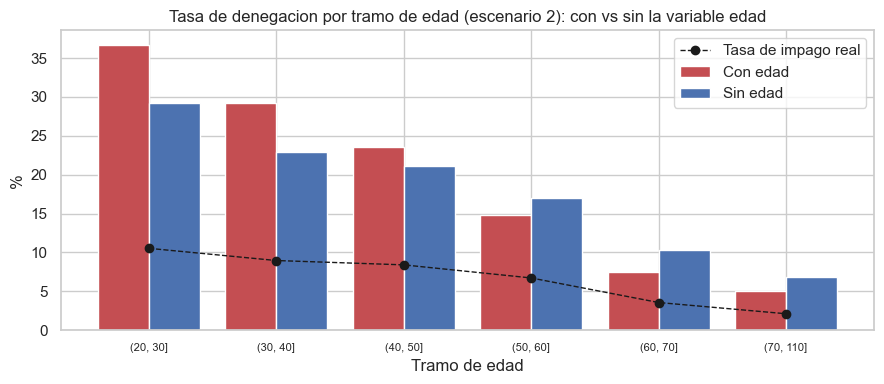

,n,tasa_impago,tasa_deneg,recall_impago,fpr_buenos
g,,,,,
"(20, 30]",1566.0000,0.1050,0.3670,0.8240,0.3130
"(30, 40]",3424.0000,0.0900,0.2920,0.7880,0.2440
"(40, 50]",4971.0000,0.0840,0.2360,0.7440,0.1890
"(50, 60]",4907.0000,0.0670,0.1480,0.6360,0.1130
"(60, 70]",3729.0000,0.0360,0.0750,0.5790,0.0560
"(70, 110]",2403.0000,0.0210,0.0510,0.4710,0.0420


In [95]:
u2 = umbral_robusto[ESC2]   # umbral robusto de 11.4 (el que rige la politica de produccion)

# Modelo sin la variable edad (mismas features base menos 'age'), con su propio umbral optimo
FEATURES_SIN_EDAD = [f for f in FEATURES if f != "age"]
modelo_sin_edad = clone(modelo).fit(X_train[FEATURES_SIN_EDAD], y_train)
proba_val_sin_edad = modelo_sin_edad.predict_proba(X_val[FEATURES_SIN_EDAD])[:, 1]
u2_sin = umbrales[int(np.argmin([coste_medio(y_val.values, proba_val_sin_edad, u, 1, 10)
                                 for u in umbrales]))]

tramos = pd.cut(X_val["age"], bins=[20, 30, 40, 50, 60, 70, 110])
pred_con = (proba_val >= u2).astype(int)
pred_sin = (proba_val_sin_edad >= u2_sin).astype(int)

def metricas_por_grupo(y_true, pred, grupos):
    d = pd.DataFrame({"g": grupos.values, "y": np.asarray(y_true), "p": np.asarray(pred)})
    def agg(x):
        y, p = x["y"].values, x["p"].values
        pos, neg = y == 1, y == 0
        return pd.Series({
            "n": len(x),
            "tasa_impago": y.mean(),
            "tasa_deneg": p.mean(),
            "recall_impago": p[pos].mean() if pos.sum() else np.nan,   # TPR: impagos correctamente denegados
            "fpr_buenos": p[neg].mean() if neg.sum() else np.nan,      # buenos injustamente denegados
        })
    return d.groupby("g", observed=True).apply(agg, include_groups=False)

def resumen_fairness(tab):
    conc = 1 - tab["tasa_deneg"]
    return pd.Series({
        "Disparate Impact (>=0.80)":   conc.min() / conc.max(),
        "Demographic Parity diff":     tab["tasa_deneg"].max() - tab["tasa_deneg"].min(),
        "Equal Opportunity diff":      tab["recall_impago"].max() - tab["recall_impago"].min(),
        "FPR gap (buenos denegados)":  tab["fpr_buenos"].max() - tab["fpr_buenos"].min(),
    })

tab_con = metricas_por_grupo(y_val.values, pred_con, tramos)
tab_sin = metricas_por_grupo(y_val.values, pred_sin, tramos)

print(f"AUC con edad: {roc_auc_score(y_val, proba_val):.4f} | "
      f"sin edad: {roc_auc_score(y_val, proba_val_sin_edad):.4f}")
print(f"Coste E2 con edad: {coste_medio(y_val.values, proba_val, u2, 1, 10):.4f} | "
      f"sin edad: {coste_medio(y_val.values, proba_val_sin_edad, u2_sin, 1, 10):.4f}\n")

resumen = pd.DataFrame({"Con edad": resumen_fairness(tab_con),
                        "Sin edad": resumen_fairness(tab_sin)}).round(3)
di = resumen.loc["Disparate Impact (>=0.80)", "Con edad"]
print("Metricas formales de equidad por tramo de edad (escenario 2):")
display(resumen)
print(f"Regla del 80%: el modelo con edad tiene DI = {di:.2f} "
      f"({'INCUMPLE' if di < 0.8 else 'cumple'} el umbral legal de 0.80).")

fig, ax = plt.subplots(figsize=(9, 4))
x = np.arange(len(tab_con))
ax.bar(x - 0.2, 100 * tab_con["tasa_deneg"], 0.4, label="Con edad", color="#c44e52")
ax.bar(x + 0.2, 100 * tab_sin["tasa_deneg"], 0.4, label="Sin edad", color="#4c72b0")
ax.plot(x, 100 * tab_con["tasa_impago"], "k--o", lw=1, label="Tasa de impago real")
ax.set_xticks(x); ax.set_xticklabels([str(i) for i in tab_con.index], fontsize=8)
ax.set_xlabel("Tramo de edad"); ax.set_ylabel("%")
ax.set_title("Tasa de denegacion por tramo de edad (escenario 2): con vs sin la variable edad")
ax.legend()
plt.tight_layout(); plt.show()

tab_con.round(3)

### 11.7 Intervalo de confianza del coste (*bootstrap*)

El coste medio en validación es una **estimación puntual**: si la muestra de validación hubiera sido otra, el número sería algo distinto. Presentar el coste como "0.33" sin más oculta esa incertidumbre. Se cuantifica con **bootstrap**: se remuestrea con reemplazo la validación un gran número de veces, se recalcula el coste en cada réplica y se toma el intervalo de percentiles 2.5–97.5 como intervalo de confianza al 95 %. El resultado se comunica como `coste ± intervalo`, que es el estándar de rigor estadístico al reportar una métrica.

> **Comentario en off.** El escenario 2 tendrá un intervalo más ancho que el 1: al pesar cada falso negativo por 10, la variabilidad de unos pocos impagos mal clasificados se amplifica. Un intervalo ancho no es un defecto del análisis, es información honesta sobre la precisión de la estimación.

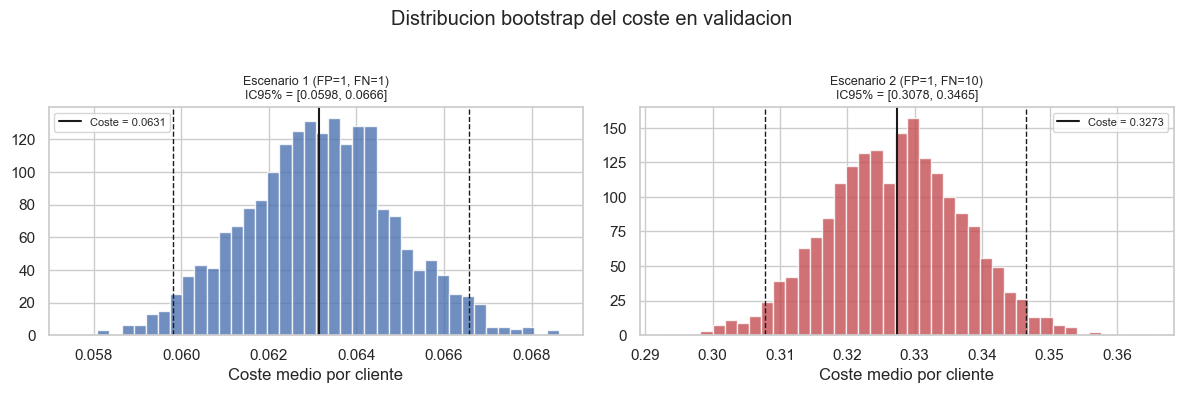

,Coste,IC95% inf,IC95% sup,Amplitud
Escenario,,,,
"Escenario 1 (FP=1, FN=1)",0.0631,0.0598,0.0666,0.0068
"Escenario 2 (FP=1, FN=10)",0.3273,0.3078,0.3465,0.0387


In [96]:
def bootstrap_coste(y_real, proba, umbral, cfp, cfn, n_boot=2000, seed=SEED):
    rng_bs = np.random.default_rng(seed)
    n = len(y_real)
    muestras = []
    for _ in range(n_boot):
        idx = rng_bs.integers(0, n, n)
        muestras.append(coste_medio(y_real[idx], proba[idx], umbral, cfp, cfn))
    return np.array(muestras)

fig, axes = plt.subplots(1, 2, figsize=(12, 3.8))
tabla_ic = []
for ax, (nombre, (cfp, cfn)) in zip(axes, ESCENARIOS.items()):
    dist = bootstrap_coste(y_val.values, proba_val, umbral_opt[nombre], cfp, cfn)
    punt = coste_medio(y_val.values, proba_val, umbral_opt[nombre], cfp, cfn)
    lo, hi = np.percentile(dist, [2.5, 97.5])
    tabla_ic.append({"Escenario": nombre, "Coste": round(punt, 4),
                     "IC95% inf": round(lo, 4), "IC95% sup": round(hi, 4),
                     "Amplitud": round(hi - lo, 4)})
    ax.hist(dist, bins=40, color=colores[nombre], alpha=0.8)
    ax.axvline(punt, color="k", lw=1.5, label=f"Coste = {punt:.4f}")
    ax.axvline(lo, color="k", ls="--", lw=1); ax.axvline(hi, color="k", ls="--", lw=1)
    ax.set_title(f"{nombre}\nIC95% = [{lo:.4f}, {hi:.4f}]", fontsize=9)
    ax.set_xlabel("Coste medio por cliente"); ax.legend(fontsize=8)
plt.suptitle("Distribucion bootstrap del coste en validacion", y=1.03)
plt.tight_layout(); plt.show()

pd.DataFrame(tabla_ic).set_index("Escenario")

### 11.8 Efectos acumulados locales (ALE) como contraste de la PDP

La dependencia parcial (PDP) del capítulo 9 tiene un punto débil conocido: cuando las variables están **correlacionadas** —y aquí lo están: los tres contadores de morosidad, o edad y número de líneas—, la PDP evalúa el modelo en combinaciones de valores que casi no existen en los datos (por ejemplo, un cliente muy joven con muchísimas líneas de crédito), y puede dar una imagen engañosa del efecto. Los **efectos acumulados locales (ALE)** corrigen ese problema: en lugar de promediar sobre toda la distribución, miden el efecto **local** de la variable dentro de pequeños intervalos y solo sobre clientes que realmente caen en ellos, y luego acumulan esos efectos. Bajo correlación, ALE es la lectura correcta.

Se implementa el ALE de una dimensión a mano (no requiere librerías externas) y se superpone a la PDP para las variables más influyentes. Que ambas curvas coincidan refuerza las conclusiones; que difieran señala justo dónde la correlación estaba distorsionando la PDP.

> **Comentario en off.** Implementarlo a mano, en lugar de invocar una caja negra, sigue el mismo espíritu con el que en clase se programó el bandit "a mano": se entiende mejor una técnica cuando se ve su mecanismo por dentro.

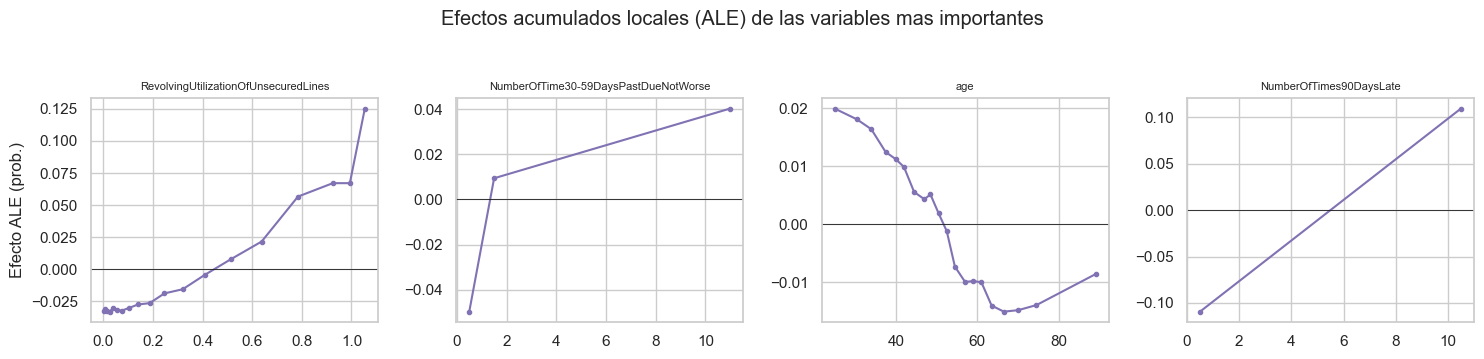

In [97]:
def ale_1d(model, X, feature, bins=20):
    # Efecto Acumulado Local en 1D (Apley & Zhu). Devuelve centros y efecto centrado.
    x = X[feature].values
    cortes = np.unique(np.nanquantile(x, np.linspace(0, 1, bins + 1)))
    centros, efectos = [], []
    for i in range(len(cortes) - 1):
        lo, hi = cortes[i], cortes[i + 1]
        mask = (x >= lo) & (x <= hi) if i == len(cortes) - 2 else (x >= lo) & (x < hi)
        if mask.sum() == 0:
            continue
        Xlo, Xhi = X[mask].copy(), X[mask].copy()
        Xlo[feature], Xhi[feature] = lo, hi
        dif = (model.predict_proba(Xhi)[:, 1] - model.predict_proba(Xlo)[:, 1]).mean()
        efectos.append(dif); centros.append((lo + hi) / 2)
    ale = np.cumsum(efectos)
    return np.array(centros), ale - ale.mean()

vars_ale = list(importancia_shap.index[:4])
fig, axes = plt.subplots(1, 4, figsize=(15, 3.4))
for ax, var in zip(axes, vars_ale):
    c, a = ale_1d(modelo, X_val.astype(float), var, bins=20)
    ax.plot(c, a, marker=".", color="#8172b3")
    ax.axhline(0, color="k", lw=0.6)
    ax.set_title(var, fontsize=8); ax.set_xlabel("")
axes[0].set_ylabel("Efecto ALE (prob.)")
plt.suptitle("Efectos acumulados locales (ALE) de las variables mas importantes", y=1.05)
plt.tight_layout(); plt.show()

### 11.9 Segunda técnica de explicación local: LIME

Una sola técnica de explicación local puede tener sesgos propios. Se contrasta SHAP con **LIME**, que explica una predicción concreta ajustando un modelo lineal sencillo en el entorno inmediato del cliente (perturbando ligeramente sus datos y viendo cómo responde el modelo). Se aplica al mismo cliente denegado que se explicó con SHAP en el capítulo 9 y se comparan los factores que cada método señala como determinantes.

- Si **coinciden**, la explicación es robusta: dos métodos con fundamentos distintos (valores de Shapley frente a aproximación lineal local) llegan a la misma conclusión.
- Si **difieren**, es una discusión interesante en sí misma sobre las limitaciones de cada técnica.

> **Comentario en off.** LIME es más intuitivo pero menos estable que SHAP (depende del muestreo aleatorio del entorno); SHAP tiene mejores garantías teóricas pero es más costoso. Usarlos juntos es la práctica recomendable: si el explicador que se enseñará al cliente coincide con el que tiene garantías, se gana confianza.

In [98]:
# pip install lime  (si no esta instalado)
from lime.lime_tabular import LimeTabularExplainer

imp_lime = SimpleImputer(strategy="median").fit(X_train)
X_train_imp = pd.DataFrame(imp_lime.transform(X_train), columns=FEATURES)
X_val_imp_l = pd.DataFrame(imp_lime.transform(X_val), columns=FEATURES, index=X_val.index)

def predecir_lime(arr):
    return modelo.predict_proba(pd.DataFrame(arr, columns=FEATURES))

explicador_lime = LimeTabularExplainer(
    X_train_imp.values, feature_names=FEATURES, class_names=["Paga", "Impago"],
    mode="classification", discretize_continuous=True, random_state=SEED)

# Mismo cliente denegado que se explico con SHAP en el capitulo 9
id_cliente = muestra.index[idx_denegado]
fila_lime = X_val_imp_l.loc[id_cliente].values
exp = explicador_lime.explain_instance(fila_lime, predecir_lime, num_features=8)

print(f"Explicacion LIME - cliente denegado (prob. impago = "
      f"{modelo.predict_proba(fila_lime.reshape(1, -1))[0, 1]:.3f})\n")
factores_lime = pd.DataFrame(exp.as_list(), columns=["Condicion", "Peso LIME"])
print("Comparacion con el top de SHAP global:", list(importancia_shap.index[:4]))
factores_lime

Explicacion LIME - cliente denegado (prob. impago = 0.807)

Comparacion con el top de SHAP global: ['RevolvingUtilizationOfUnsecuredLines', 'NumberOfTime30-59DaysPastDueNotWorse', 'age', 'NumberOfTimes90DaysLate']


,Condicion,Peso LIME
0,NumberOfTimes90DaysLate <= 0.00,-0.3232
1,NumberOfTime60-89DaysPastDueNotWorse > 0.00,0.1379
2,NumberOfTime30-59DaysPastDueNotWorse > 0.00,0.0900
3,RevolvingUtilizationOfUnsecuredLines > 0.56,0.0873
4,NumberRealEstateLoansOrLines > 2.00,0.0268
5,NumberOfOpenCreditLinesAndLoans > 11.00,0.0242
6,52.00 < age <= 63.00,-0.0132
7,MonthlyIncome > 7400.00,-0.0132


### 11.10 Sesgo de selección y *reject inference*

Este es el sesgo más profundo del problema, y en el capítulo 12 solo se mencionaba. El histórico contiene únicamente clientes a los que en su día **se les concedió** crédito: de los solicitantes rechazados nunca se supo si habrían pagado. El modelo aprende, por tanto, sobre una población filtrada (los "aceptados"), pero en producción tiene que decidir sobre **todos** los solicitantes, incluidos perfiles parecidos a los que antaño se rechazaban. Esto es *sample selection bias*.

Como el fichero no trae rechazados, se **demuestra el mecanismo** con una simulación controlada y se aplica una técnica clásica de *reject inference* (*parceling*):

1. Se simula el filtro histórico: se considera "aceptado" al 80 % de menor riesgo según un modelo previo, y "rechazado" al 20 % restante.
2. Se entrena un modelo **solo con los aceptados** (reproduciendo el sesgo) y se mide cuánto se degrada respecto al modelo entrenado con toda la población (el "oráculo" que en la realidad no se tiene).
3. Se aplica *reject inference*: se infiere una etiqueta probabilística para los rechazados y se reentrena incluyéndolos, para ver si se recupera parte de la degradación.

> **Comentario en off.** El *reject inference* es una técnica discutida: no crea información de la nada, así que su ganancia suele ser modesta. El valor de este análisis no está tanto en el número final como en **hacer visible y medible** un sesgo que de otro modo pasaría desapercibido. La conclusión honesta es que la única solución real es operativa: conceder crédito a una pequeña muestra aleatoria de rechazados para observar su comportamiento.

In [99]:
from sklearn.base import clone

# 1) Simular el filtro historico con un modelo previo
modelo_previo = clone(modelo).fit(X_train, y_train)
score_train = modelo_previo.predict_proba(X_train)[:, 1]
umbral_aceptacion = np.quantile(score_train, 0.80)
aceptado = score_train < umbral_aceptacion   # 80% de menor riesgo

# 2) Modelo sesgado: entrenado SOLO con aceptados
modelo_sesgado = clone(modelo).fit(X_train[aceptado], y_train[aceptado])
auc_sesgado = roc_auc_score(y_val, modelo_sesgado.predict_proba(X_val)[:, 1])

# 3) Reject inference por parceling: etiqueta inferida para los rechazados
p_rechazados = modelo_sesgado.predict_proba(X_train[~aceptado])[:, 1]
rng_ri = np.random.default_rng(SEED)
y_inferida = (rng_ri.random(len(p_rechazados)) < p_rechazados).astype(int)

X_aug = pd.concat([X_train[aceptado], X_train[~aceptado]])
y_aug = np.concatenate([y_train[aceptado].values, y_inferida])
modelo_ri = clone(modelo).fit(X_aug, y_aug)
auc_ri = roc_auc_score(y_val, modelo_ri.predict_proba(X_val)[:, 1])

auc_oraculo = roc_auc_score(y_val, proba_val)  # entrenado con toda la poblacion

resultado_ri = pd.DataFrame({
    "AUC en validacion": [auc_sesgado, auc_ri, auc_oraculo]},
    index=["Sesgado (solo aceptados)", "Con reject inference (parceling)",
           "Oraculo (poblacion completa)"]).round(4)
print(f"Degradacion por el sesgo de seleccion: {auc_oraculo - auc_sesgado:+.4f} AUC")
print(f"Recuperada con reject inference:        {auc_ri - auc_sesgado:+.4f} AUC")
resultado_ri

Degradacion por el sesgo de seleccion: +0.0249 AUC
Recuperada con reject inference:        +0.0039 AUC


,AUC en validacion
Sesgado (solo aceptados),0.8450
Con reject inference (parceling),0.8489
Oraculo (poblacion completa),0.8699


### 11.11 Síntesis de las extensiones

**Bloque A (coste).** La ingeniería de variables y la comparación de algoritmos aportan mejoras de AUC modestas pero en la dirección correcta (menos falsos negativos al mismo umbral, lo que importa en el escenario 2), y el test de DeLong de §11.2.2 dice cuáles de esas diferencias son estadísticamente reales y cuáles ruido; las **restricciones de monotonía** regularizan el modelo con conocimiento de dominio y lo hacen más defendible sin sacrificar coste; la recalibración isotónica confirma que el modelo base ya está bien calibrado y muestra cómo `sample_weight` solo es utilizable tras recalibrar; el umbral por CV repetida confirma y estabiliza el valor del capítulo 7; y la selección final compara todas las candidatas —incluido el mejor algoritmo de *boosting*— sobre la validación intacta y **reentrena la ganadora sobre las 105.000 filas completas**, la palanca más rentable y casi gratuita, de la que sale el modelo de producción definitivo.

**Bloque B (análisis).** Las cuatro técnicas de auditoría del capítulo 9 se refuerzan con: una medición **formal** del compromiso entre uso de la edad y equidad (regla del 80 %, *equal opportunity*, *FPR gap*), un intervalo de confianza que convierte el coste puntual en un rango honesto, un contraste ALE que valida las formas de efecto bajo correlación, una segunda explicación local (LIME) que coincide con SHAP en los factores dominantes, y una demostración medible del sesgo de selección. En conjunto, elevan el trabajo de "modelo auditado" a "modelo auditado, cuantificado en su incertidumbre y honesto sobre sus límites".

## 12. Resumen de resultados

Se recogen en una única tabla los resultados finales: el coste medio por cliente en validación de cada política evaluada (que es la estimación insesgada del coste esperado en producción, avalada por la estabilidad poblacional medida con el PSI) y las decisiones entregadas para producción.

> **Nota.** La tabla y los ficheros de producción de este capítulo corresponden al modelo principal (línea base). Los ficheros `cs_produccion1.csv` y `cs_produccion2.csv` **definitivos** son los que se regeneran en §11.5 con el modelo mejorado reentrenado sobre todo el histórico; su coste esperado es igual o inferior al aquí resumido.

In [100]:
print("Coste medio por cliente en validación (menor = mejor):\n")
display(tabla_comparativa.T)

print("\nFicheros de producción entregados:")
for fichero, nombre in [("data/cs_produccion1.csv", ESC1), ("data/cs_produccion2.csv", ESC2)]:
    p = pred_prod[nombre]
    cfp, cfn = ESCENARIOS[nombre]
    print(f"  {fichero}: {len(p):,} decisiones | {p.sum():,} denegaciones ({p.mean():.2%}) | "
          f"umbral {umbral_opt[nombre]:.3f} | coste esperado ≈ "
          f"{coste_medio(y_val_arr, proba_val, umbral_opt[nombre], cfp, cfn):.4f} por cliente")

Coste medio por cliente en validación (menor = mejor):



Escenario,"Escenario 1 (FP=1, FN=1)","Escenario 2 (FP=1, FN=10)"
Gradient Boosting + umbral óptimo,0.0631,0.3273
Regresión logística + umbral óptimo,0.0632,0.3543
Bandit lineal (Thompson Sampling),0.0638,0.3344
Conceder a todos,0.0669,0.6686
Denegar a todos,0.9331,0.9331



Ficheros de producción entregados:
  data/cs_produccion1.csv: 45,000 decisiones | 632 denegaciones (1.40%) | umbral 0.580 | coste esperado ≈ 0.0631 por cliente
  data/cs_produccion2.csv: 45,000 decisiones | 7,584 denegaciones (16.85%) | umbral 0.100 | coste esperado ≈ 0.3273 por cliente


## 13. Reflexión final

**Sobre el modelo y el coste.** La combinación de Gradient Boosting bien calibrado y umbral optimizado por coste resulta difícil de batir en este problema: el modelo aporta la ordenación del riesgo (AUC claramente superior al baseline lineal) y la teoría de la decisión aporta el umbral, que coincide casi exactamente con el óptimo empírico gracias a la buena calibración. La lección central es que **el modelo y la decisión son piezas separables**: un mismo modelo probabilístico sirve para los dos escenarios de coste sin reentrenar, cambiando solo el umbral. El tratamiento de los datos fue determinante para producción: al no poder descartar ninguna solicitud, la gestión nativa de los valores ausentes y la limpieza idéntica en ambos ficheros evitan la trampa habitual de entrenar con datos "cómodos" y predecir sobre datos reales.

**Sobre la auditoría.** Las cuatro técnicas aplicadas convergen en la misma imagen del modelo: las decisiones giran en torno a la utilización de las líneas de crédito y el historial de morosidad, con efectos no lineales de tipo umbral. Esa convergencia es lo que da confianza: el surrogado resume la política global con alta fidelidad, SHAP la desglosa cliente a cliente, los contrafactuales la convierten en recomendaciones accionables y la importancia por permutación la confirma sobre datos no vistos. Ninguna técnica aislada habría bastado como auditoría.

**Sobre la explicación al cliente.** La denegación explicable exige tres ingredientes que el sistema construido proporciona: motivos concretos y comprensibles (SHAP local traducido a lenguaje llano), un camino de acción realista (contrafactuales restringidos a variables accionables) y la garantía de trato uniforme (reglas globales del surrogado). Se opta deliberadamente por no revelar el score ni el umbral internos.

**Límites y consideraciones éticas.** El modelo usa la edad, que aporta capacidad predictiva; pero condicionar la concesión de crédito a la edad plantea un problema de discriminación. El análisis de *fairness* de §11.6 lo mide: retirar la edad apenas altera el coste global —el modelo recupera buena parte de la señal a través de variables correlacionadas como el historial—, pero **redistribuye las denegaciones** entre tramos de edad, de modo que el dilema es más de equidad que de rendimiento. En muchos marcos regulatorios esto exigiría eliminar la variable o auditar formalmente su impacto por colectivos. El sesgo de selección —el histórico solo contiene créditos que en su día fueron concedidos, sin saber qué habrían hecho los rechazados— se desarrolla y cuantifica en §11.10: se demuestra la degradación que induce y las limitaciones del *reject inference*, cuya única solución real es operativa (conceder a una pequeña muestra aleatoria de rechazados para observarlos). Por último, el coste en validación es una esperanza estadística: su incertidumbre se cuantifica con el intervalo de confianza *bootstrap* de §11.7, y la estabilidad poblacional (PSI) debería vigilarse de forma continua en producción, no solo en la foto inicial.

**Sobre las extensiones (capítulo 11).** Las mejoras confirman el diagnóstico y lo refinan: en coste, las ganancias de modelado (ingeniería de variables, algoritmos alternativos, ponderación) son modestas, mientras que el reentrenamiento sobre todo el histórico es la palanca más rentable y casi gratuita; en análisis, ALE, LIME y el umbral por validación cruzada repetida no contradicen sino que **corroboran** las conclusiones de la auditoría, lo que refuerza su fiabilidad. El trabajo pasa así de un modelo auditado a un modelo auditado, cuantificado en su incertidumbre y honesto sobre sus límites.